In [30]:
import os
import ast

if "PATH_SET" not in locals():
    os.chdir("../..")
    PATH_SET = True

import torch

if "THREADS_SET" not in locals():
    try:
        os.environ["OMP_NUM_THREADS"] = "5"
        os.environ["MKL_NUM_THREADS"] = "5"

        torch.set_num_threads(5)
        torch.set_num_interop_threads(5)
        THREADS_SET = True
    except:
        pass

import numpy as np
import xarray as xr
import pandas as pd
from scipy.interpolate import RegularGridInterpolator

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.style as style

style.use(
    "https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle_background.mplstyle"
)

In [31]:
from helpers.geographic_setup import design_space_full, topo_data, grid_coords

from helpers.helper_functions import (
    SurfaceField_Distribution,
    concave_hull2D_prior_dist_constructor,
)


from helpers.likelihood import (
    DataLikelihoodAttenuation,
    DataLikelihood,
    logistic_picking_likelihood_tt,
)
from helpers.forward import TTLookup

from helpers.transparent_colormaps import blue_cmap

In [32]:
design_df = pd.read_csv("generate_designs/data/design_data.csv")

design_df = design_df[design_df["study_area"] == "full"]
# Reset DataFrame indices to avoid potential issues
design_df = design_df.reset_index(drop=True)

# Check for missing or problematic columns
required_columns = [
    "study_area",
    "model_prior",
    "velocity_model",
    "vel_sigma",
    "noise_correlation",
    "drop_mean",
    "drop_gradient",
    "optimisation",
    "EIG_method",
    "EIG_N",
    "design",
]
missing_columns = [col for col in required_columns if col not in design_df.columns]
if missing_columns:
    print(f"Warning: Missing columns in design_df: {missing_columns}")

# Convert design column from string to tensor if needed
if "design" in design_df.columns and isinstance(design_df["design"].iloc[0], str):
    design_df["design"] = design_df["design"].apply(
        lambda x: torch.tensor(ast.literal_eval(x))
    )

In [33]:
import os

summary_statistics_file = "benchmark_designs/full/data/summary_statistics.csv"

if os.path.exists(summary_statistics_file):
    summary_statistics = pd.read_csv(summary_statistics_file)
    print(f"Loaded summary statistics from {summary_statistics_file}")
else:
    raise FileNotFoundError(
        f"Summary statistics file not found: {summary_statistics_file}"
    )
summary_statistics = summary_statistics[
    summary_statistics["optimisation"].isin(["iterative", "genetic"])]

summary_statistics = summary_statistics[
    ~((summary_statistics['EIG_method'] == 'DN') & (summary_statistics['drop_mean'] != 0.0))
]
summary_statistics['std'] = np.sqrt(
    summary_statistics['std_x'] ** 2 + summary_statistics['std_y'] **
    2 + summary_statistics['std_z'] ** 2
)

summary_statistics["attenuation"] = summary_statistics["drop_mean"].apply(
    lambda x: "yes" if x > 0 else "no"
)
summary_statistics['drop_gradient'] = -summary_statistics['drop_gradient']


Loaded summary statistics from benchmark_designs/full/data/summary_statistics.csv


In [34]:
import os

random_stats_file = "benchmark_designs/full/data/random_stats.csv"
sobol_stats_file = "benchmark_designs/full/data/sobol_stats.csv"

if os.path.exists(random_stats_file):
    random_stats_df = pd.read_csv(random_stats_file)
else:
    raise FileNotFoundError(
        f"Random stats file not found: {random_stats_file}. Please generate it first."
    )
    
if os.path.exists(sobol_stats_file):
    sobol_stats_df = pd.read_csv(sobol_stats_file)
else:
    raise FileNotFoundError(
        f"Sobol stats file not found: {sobol_stats_file}. Please generate it first."
    )

random_stats_df['std'] = np.sqrt(
    random_stats_df['std_x'] ** 2 + random_stats_df['std_y'] ** 2 + random_stats_df['std_z'] ** 2
) 
sobol_stats_df['std'] = np.sqrt(
    sobol_stats_df['std_x'] ** 2 + sobol_stats_df['std_y'] ** 2 + sobol_stats_df['std_z'] ** 2
)

random_stats_df = random_stats_df[
    random_stats_df['N_rec'] <= 10
]
sobol_stats_df = sobol_stats_df[
    sobol_stats_df['N_rec'] <= 10
]

In [35]:
# Add design_index to random_stats_df and sobol_stats_df
# design_index is the index within each (N_rec, event_index) group


def add_design_index(df):
    # If already present, do not add again
    if "design_index" in df.columns:
        return df
    # Assign design_index within each (N_rec, event_index) group
    df = df.copy()
    df["design_index"] = df.groupby(["N_rec", "event_index"]).cumcount()
    return df


random_stats_df = add_design_index(random_stats_df)
sobol_stats_df = add_design_index(sobol_stats_df)

# Get Combined Statistics

In [36]:
scen_columns = [
    "study_area",
    "model_prior",
    "velocity_model",
    "vel_sigma",
    "noise_correlation",
    "drop_mean",
    "drop_gradient",
    "attenuation",
    "optimisation",
    "EIG_method",
    "EIG_N",
]

stat_columns = [
    "mean_x",
    "mean_y",
    "mean_z",
    "std_x",
    "std_y",
    "std_z",
    "std",
    "distance_mean",
    "distance_map",
    "p_posterior",
    "posterior_entropy",
    "posterior_information",
    "prior_entropy",
    "prior_information",
]

In [37]:
design_stats = summary_statistics.drop(columns="design").groupby(
    scen_columns + ["N_rec"]
).agg(
    {
        "mean_x": "mean",
        "mean_y": "mean",
        "mean_z": "mean",
        "std_x": "mean",
        "std_y": "mean",
        "std_z": "mean",
        "std": "mean",
        "distance_mean": "mean",
        "distance_map": "mean",
        "p_posterior": "mean",
        "posterior_entropy": "mean",
        "posterior_information": "mean",
        "prior_entropy": "mean",
        "prior_information": "mean",
    }
).reset_index()


display(design_stats)

design_stats = design_stats[
    design_stats['optimisation'].isin(['iterative', 'genetic'])
]
design_stats = design_stats[
    design_stats['N_rec'] <= 10
]

,study_area,model_prior,velocity_model,vel_sigma,noise_correlation,drop_mean,drop_gradient,attenuation,optimisation,EIG_method,...,std_y,std_z,std,distance_mean,distance_map,p_posterior,posterior_entropy,posterior_information,prior_entropy,prior_information
0,full,displacement,gradient,0.005,100,0.00,0,no,genetic,DN,...,310.797216,172.662729,450.631865,437.521652,412.619619,0.000045,19.501460,-19.501460,19.955247,-19.955247
1,full,displacement,gradient,0.005,100,0.00,0,no,genetic,DN,...,286.070754,162.357573,386.775022,401.976721,344.631128,0.000088,18.974241,-18.974241,19.955247,-19.955247
2,full,displacement,gradient,0.005,100,0.00,0,no,genetic,DN,...,201.393578,128.740301,290.968226,260.137663,247.116337,0.000196,18.375279,-18.375279,19.955247,-19.955247
3,full,displacement,gradient,0.005,100,0.00,0,no,genetic,DN,...,210.886208,130.979311,295.255571,284.593248,239.640644,0.000189,18.191318,-18.191318,19.955247,-19.955247
4,full,displacement,gradient,0.005,100,0.00,0,no,genetic,DN,...,159.160063,100.787012,233.301386,215.252695,198.716117,0.000339,17.787459,-17.787459,19.955247,-19.955247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3510,full,uniform,homogeneous,0.100,100,0.35,30,yes,iterative,NMC,...,170.073164,103.360913,239.351127,226.646293,217.600202,0.000454,17.839483,-17.839483,19.955247,-19.955247
3511,full,uniform,homogeneous,0.100,100,0.35,30,yes,iterative,NMC,...,166.939648,101.902317,232.132726,213.014451,199.107615,0.000840,17.617451,-17.617451,19.955247,-19.955247
3512,full,uniform,homogeneous,0.100,100,0.35,30,yes,iterative,NMC,...,162.472189,100.508679,225.525373,217.349945,206.671925,0.000716,17.569970,-17.569970,19.955247,-19.955247
3513,full,uniform,homogeneous,0.100,100,0.35,30,yes,iterative,NMC,...,147.631307,95.769484,204.807281,189.908227,184.128238,0.000836,17.258009,-17.258009,19.955247,-19.955247


In [38]:
# First, group by N_rec and event_index, then average over events for each design_index
random_grouped = (
    random_stats_df.groupby(
        [
            "N_rec",
            "design_index",
        ]
    )[stat_columns]
    .mean()
    .reset_index()
)

sobol_grouped = (
    sobol_stats_df.groupby(
        [
            "N_rec",
            "design_index",
        ]
    )[stat_columns]
    .mean()
    .reset_index()
)

design_stats_grouped = (
    design_stats.groupby(
        scen_columns + ["N_rec"]
    )[stat_columns]
    .mean()
    .reset_index()
)


In [39]:
design_stats_entropy = summary_statistics.drop(columns="design").groupby(
    scen_columns + ["N_rec"]
).agg(
    {
        "mean_x": "mean",
        "mean_y": "mean",
        "std_x": "mean",
        "std_y": "mean",
        "std": "mean",
        "distance_mean": "mean",
        "distance_map": "mean",
        "p_posterior": "mean",
        "posterior_entropy": "mean",
        "posterior_information": "mean",
        "prior_entropy": "mean",
        "prior_information": "mean",
    }
).reset_index()

design_stats_entropy = design_stats_entropy[
    design_stats_entropy['model_prior'].isin(['displacement']) &
    design_stats_entropy['optimisation'].isin(['iterative']) &
    design_stats_entropy['vel_sigma'].isin([0.05]) &
    design_stats_entropy['noise_correlation'].isin([100.0]) &
    design_stats_entropy['drop_mean'].isin([0.0, 0.35]) &
    design_stats_entropy['drop_gradient'].isin([0.0, 30.0]) &
    design_stats_entropy['EIG_N'].isin([1000])
]
design_stats_entropy = design_stats_entropy[design_stats_entropy["N_rec"] <= 30]

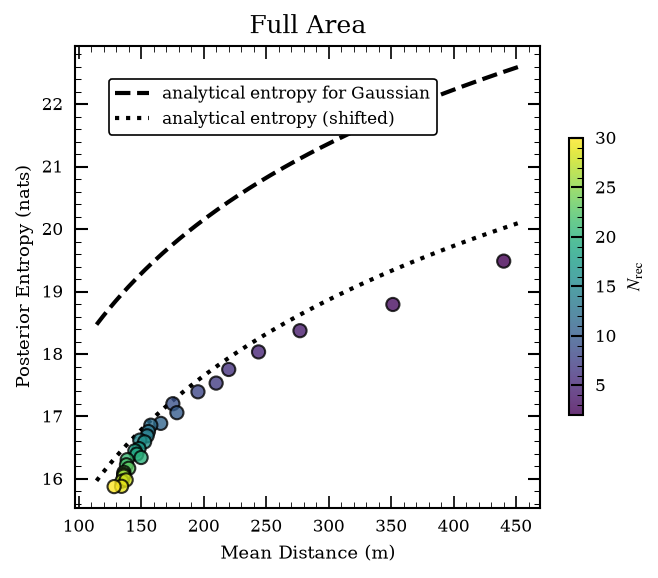

In [40]:
# property = 'std'
property = "distance_mean"
# property = 'distance_map'


# Take mean over property and entropy for each receiver value
mean_df = (
    design_stats_entropy.groupby("N_rec")[[property, "posterior_entropy"]]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(5, 4))
sc = ax.scatter(
    mean_df[property],
    mean_df["posterior_entropy"],
    c=mean_df["N_rec"],
    cmap="viridis",
    marker='o',
    s=40, linewidths=1,
    edgecolor="k",
    alpha=0.8,
    zorder=2,
)
ax.set_xlabel("Mean Distance (m)")
ax.set_ylabel("Posterior Entropy (nats)")
cbar = fig.colorbar(sc, ax=ax, label=r"$N_\text{rec}$", shrink=0.6)

# Add line: m + 0.5 * log(distance_mean)
x_line = np.linspace(
    design_stats_entropy[property].min(), design_stats_entropy[property].max() - 20, 200
)

k = 3
entropy = k/2 * np.log(2 * np.e * np.pi * x_line**2)
ax.plot(x_line, entropy, color='k', linestyle='--', linewidth=2, label='analytical entropy for Gaussian', zorder=1)
ax.plot(x_line, entropy-2.5, color='k', linestyle=':', linewidth=2, label='analytical entropy (shifted)', zorder=1)

ax.legend(loc='upper left', fontsize=8, facecolor='white')
ax.set_title("Full Area", fontsize=12)

fig.savefig("figures/full_posterior_entropy_vs_distance_mean.pdf", bbox_inches='tight')
fig.savefig("figures/full_posterior_entropy_vs_distance_mean.png", bbox_inches='tight')

plt.show()

In [41]:
from matplotlib.lines import Line2D


quantity_labels = {
    'distance_mean': 'Mean Distance (m)',
    'distance_map': 'MAP Distance (m)',
    'posterior_entropy': 'Posterior Entropy (nats)',
    'EIG': 'Expected Information Gain (nats)',
    'N_rec': 'Number of Receivers',
}

legend_label_map = {
    'EIG_method': 'EIG Method',
    'EIG_N': r'$N_\text{EIG}$',
    'velocity_model': 'Vel. Model',
    'drop_mean': r'Drop Mean',
    'drop_gradient': r'Drop Gradient',
    'optimisation': 'Optimisation',
    'vel_sigma': r'$\sigma_\text{vel}$',
    'noise_correlation': r'Noise Cor.',
    'model_prior': 'Model Prior',
    'attenuation': 'Attenuation',
}

title_label_map = {
    'EIG_method': 'EIG Method',
    'EIG_N': r'Number of Samples $N_\text{EIG}$',
    'velocity_model': 'Velocity Model',
    'drop_mean': r'Drop Mean',
    'drop_gradient': r'Drop Gradient',
    'optimisation': 'Optimisation',
    'vel_sigma': r'Velocity Uncertainty $\sigma_\text{vel}$',
    'noise_correlation': r'Noise Correlation',
    'model_prior': 'Model Prior',
    'attenuation': 'Attenuation',
}

def plot_combinations(
    ax,
    data,
    x_quantity,
    y_quantity,
    param1,
    param2=None,
    color_dict=None,
    marker_dict=None,
    random_grouped=random_grouped,
    sobol_grouped=sobol_grouped,
    background_alpha=0.35,
    title=None,
    # attenuation=None,
    set_defaults=True,
    select_matching=True,
    N_rec_min=2,
    N_rec_max=10,
):
    """
    Plot combinations of parameters with optional background (random/sobol) and custom legends.
    """

    if set_defaults:
        select_matching = False

    # # Take mean over N_rec from min to max
    data = data[(data['N_rec'] >= N_rec_min) & (data['N_rec'] <= N_rec_max)]
    data = data.groupby(scen_columns).mean().reset_index()
    data = data.reset_index(drop=True)

    data_original = data.copy()


    # always filter for displacement model prior
    if 'model_prior' not in [param1, param2]:
        data = data[data['model_prior'] == 'displacement']

    # Filtering for unbiased comparison
    if set_defaults:
        if 'EIG_method' not in [param1, param2]:
            data = data[data['EIG_method'] == 'NMC']
        if 'EIG_N' not in [param1, param2]:
            data = data[data['EIG_N'] == 1000]
        if 'optimisation' not in [param1, param2]:
            data = data[data['optimisation'].isin(['genetic', 'iterative'])]
        if 'drop_mean' not in [param1, param2]:
            data = data[(data['drop_mean'] == 0.35) | (data['drop_mean'] == 0.0)]
        if 'drop_gradient' not in [param1, param2]:
            data = data[(data['drop_gradient'] == 0.0) | (data['drop_gradient'] == 30.0)]
        if 'velocity_model' not in [param1, param2]:
            data = data[data['velocity_model'] == 'gradient']
        if 'vel_sigma' not in [param1, param2]:
            data = data[
                ((data['velocity_model'] == 'heterogeneous') & (data['vel_sigma'] == 0.01))
                | ((data['velocity_model'].isin(['gradient', 'homogeneous'])) & (data['vel_sigma'] == 0.05))
            ]
        if 'noise_correlation' not in [param1, param2]:
            data = data[data['noise_correlation'] == 100.0]

    param_cols = [param1] + ([param2] if param2 and param1 != param2 else [])
    other_cols = [c for c in ['model_prior', 'velocity_model', 'vel_sigma', 'noise_correlation',
                              'drop_mean', 'drop_gradient', 'optimisation', 'EIG_method', 'EIG_N']
                  if c not in param_cols]

    # if attenuation is not None:
    #     if attenuation:
    #         data = data[data['drop_mean'] > 0.0]
    #     else:
    #         data = data[data['drop_mean'] == 0.0]

    if select_matching:
        grouped = data.groupby(other_cols)
        valid_indices = []
        for name, group in grouped:
            param_combinations = data[param_cols].drop_duplicates()
            group_combinations = group[param_cols].drop_duplicates()
            if len(group_combinations) == len(param_combinations):
                valid_indices.extend(group.index.tolist())
        valid_indices = pd.Index(valid_indices)
        data = data.loc[valid_indices]

    multipl = 2.0

    size_map = {
        'p': 30*multipl,
        's': 25*multipl,
        '^': 35*multipl,
        'o': 20*multipl,
        'X': 20*multipl,
        'P': 20*multipl,
        '*': 30*multipl,
    }

    # Plot background (random and sobol), averaged over receiver range
    if random_grouped is not None:
        random_avg = random_grouped[(random_grouped['N_rec'] >= N_rec_min) & (random_grouped['N_rec'] <= N_rec_max)]
        random_avg = random_avg.groupby(['design_index'])[[x_quantity, y_quantity]].mean().reset_index()
        ax.scatter(
            random_avg[x_quantity], random_avg[y_quantity],
            edgecolors='none', color='grey', alpha=background_alpha, s=15, label='_nolegend_', zorder=1,
            rasterized=True
        )
    if sobol_grouped is not None:
        sobol_avg = sobol_grouped[(sobol_grouped['N_rec'] >= N_rec_min) & (sobol_grouped['N_rec'] <= N_rec_max)]
        sobol_avg = sobol_avg.groupby(['design_index'])[[x_quantity, y_quantity]].mean().reset_index()
        ax.scatter(
            sobol_avg[x_quantity], sobol_avg[y_quantity],
            edgecolors='none', color='tab:olive', alpha=background_alpha, s=15, label='_nolegend_', zorder=1,
            rasterized=True
        )

    # Plot main points
    for _, row in data.iterrows():
        marker = marker_dict.get(row[param1], 'o') if marker_dict else 'o'
        marker_size = size_map.get(marker, 100)
        color = color_dict.get(row[param2], 'gray') if (color_dict and param2) else 'gray'
        edge_color = 'darkred' if row.get('attenuation') == 'yes' else 'black'
        ax.scatter(
            row[x_quantity], row[y_quantity],
            marker=marker, facecolor=color, edgecolor=edge_color, linewidth=1.2, alpha=1.0, s=marker_size, zorder=10,
        )


    ax.set_xlabel(quantity_labels.get(x_quantity, x_quantity), fontsize=10)
    ax.set_ylabel(
        quantity_labels.get(y_quantity, y_quantity), fontsize=10,
        rotation=90, labelpad=10
    )
                  
    ax.grid(True, linestyle='--', alpha=0.5)
    if title is not None:
        # if isinstance(title, (tuple, list)) and len(title) == 2:
        #     label1 = title_label_map.get(title[0], str(title[0]))
        #     label2 = title_label_map.get(title[1], str(title[1]))
        #     ax.set_title(f"{label1} vs {label2}", fontsize=11)
        # elif isinstance(title, str) and ' vs ' in title:
        #     t1, t2 = title.split(' vs ', 1)
        #     label1 = title_label_map.get(t1, t1)
        #     label2 = title_label_map.get(t2, t2)
        #     ax.set_title(f"{label1} vs {label2}", fontsize=11)
        # else:
        #     label = title_label_map.get(title, title)
        ax.set_title(title, fontsize=11)
            
    # Custom legend
    legend_elements_marker = []
    legend_elements_color = []
    if param1 == param2 and marker_dict and color_dict:
        for key in marker_dict:
            marker = marker_dict[key]
            color = color_dict.get(key, 'gray')
            label = legend_label_map.get(param1, param1)
            if (
                param1 in ['drop_mean', 'drop_gradient']
                and isinstance(marker_dict, dict)
                and len(marker_dict) == 2
                and (isinstance(key, (int, float)) and key > 0)
            ):
                legend_label = 'Attenuation'
            elif param1 in ['drop_mean', 'drop_gradient'] and (key == 0.0 or key == 0):
                legend_label = 'No Attenuation'
            else:
                legend_label = f'{label} = {key}'
            legend_elements_marker.append(
                Line2D([0], [0], marker=marker, color='w', label=legend_label,
                    markeredgewidth=1.0, markerfacecolor=color, markeredgecolor='black', markersize=7.5, linestyle='None')
            )
        legend1 = ax.legend(handles=legend_elements_marker, loc='upper left', fontsize=7, facecolor='white')
        ax.add_artist(legend1)
    else:
        if marker_dict:
            for key, marker in marker_dict.items():
                label = legend_label_map.get(param1, param1)
                if (
                    param1 in ['drop_mean', 'drop_gradient']
                    and isinstance(marker_dict, dict)
                    and len(marker_dict) == 2
                    and (isinstance(key, (int, float)) and key > 0)
                ):
                    legend_label = 'Attenuation'
                elif param1 in ['drop_mean', 'drop_gradient'] and (key == 0.0 or key == 0):
                    legend_label = 'No Attenuation'
                else:
                    legend_label = f'{label} = {key}'
                legend_elements_marker.append(
                    Line2D([0], [0], marker=marker, color='w', label=legend_label,
                        markeredgewidth=1.0, markerfacecolor='gray', markeredgecolor='black', markersize=7.5, linestyle='None')
                )
        if color_dict and param2:
            for key, color in color_dict.items():
                label = legend_label_map.get(param2, param2)
                if (
                    param2 in ['drop_mean', 'drop_gradient']
                    and isinstance(color_dict, dict)
                    and len(color_dict) == 2
                    and (isinstance(key, (int, float)) and key > 0)
                ):
                    legend_label = 'Attenuation'
                elif param2 in ['drop_mean', 'drop_gradient'] and (key == 0.0 or key == 0):
                    legend_label = 'No Attenuation'
                else:
                    legend_label = f'{label} = {key}'
                legend_elements_color.append(
                    Line2D([0], [0], marker='o', color='w', label=legend_label,
                        markeredgewidth=1.0, markerfacecolor=color, markeredgecolor='black', markersize=7.5, linestyle='None')
                )
        legend1 = None
        legend2 = None
        if legend_elements_marker:
            legend1 = ax.legend(handles=legend_elements_marker, loc='upper left', fontsize=7, facecolor='white')
            ax.add_artist(legend1)
        if legend_elements_color:
            legend2 = ax.legend(handles=legend_elements_color, loc='lower right', fontsize=7, facecolor='white')
            ax.add_artist(legend2)

    if y_quantity == 'EIG':
        ax.invert_yaxis()

    # Calculate limits based on the original data after mean over receivers
    x_min, x_max = data_original[x_quantity].min(), data_original[x_quantity].max()
    y_min, y_max = data_original[y_quantity].min(), data_original[y_quantity].max()

    # # Set limits with a small margin
    # margin_x = (x_max - x_min) * 0.2
    # margin_y = (y_max - y_min) * 0.2
    # ax.set_xlim(x_min - margin_x*0.5, x_max + margin_x)
    # ax.set_ylim(y_min - margin_y*0.5, y_max + margin_y)
    
    return ax

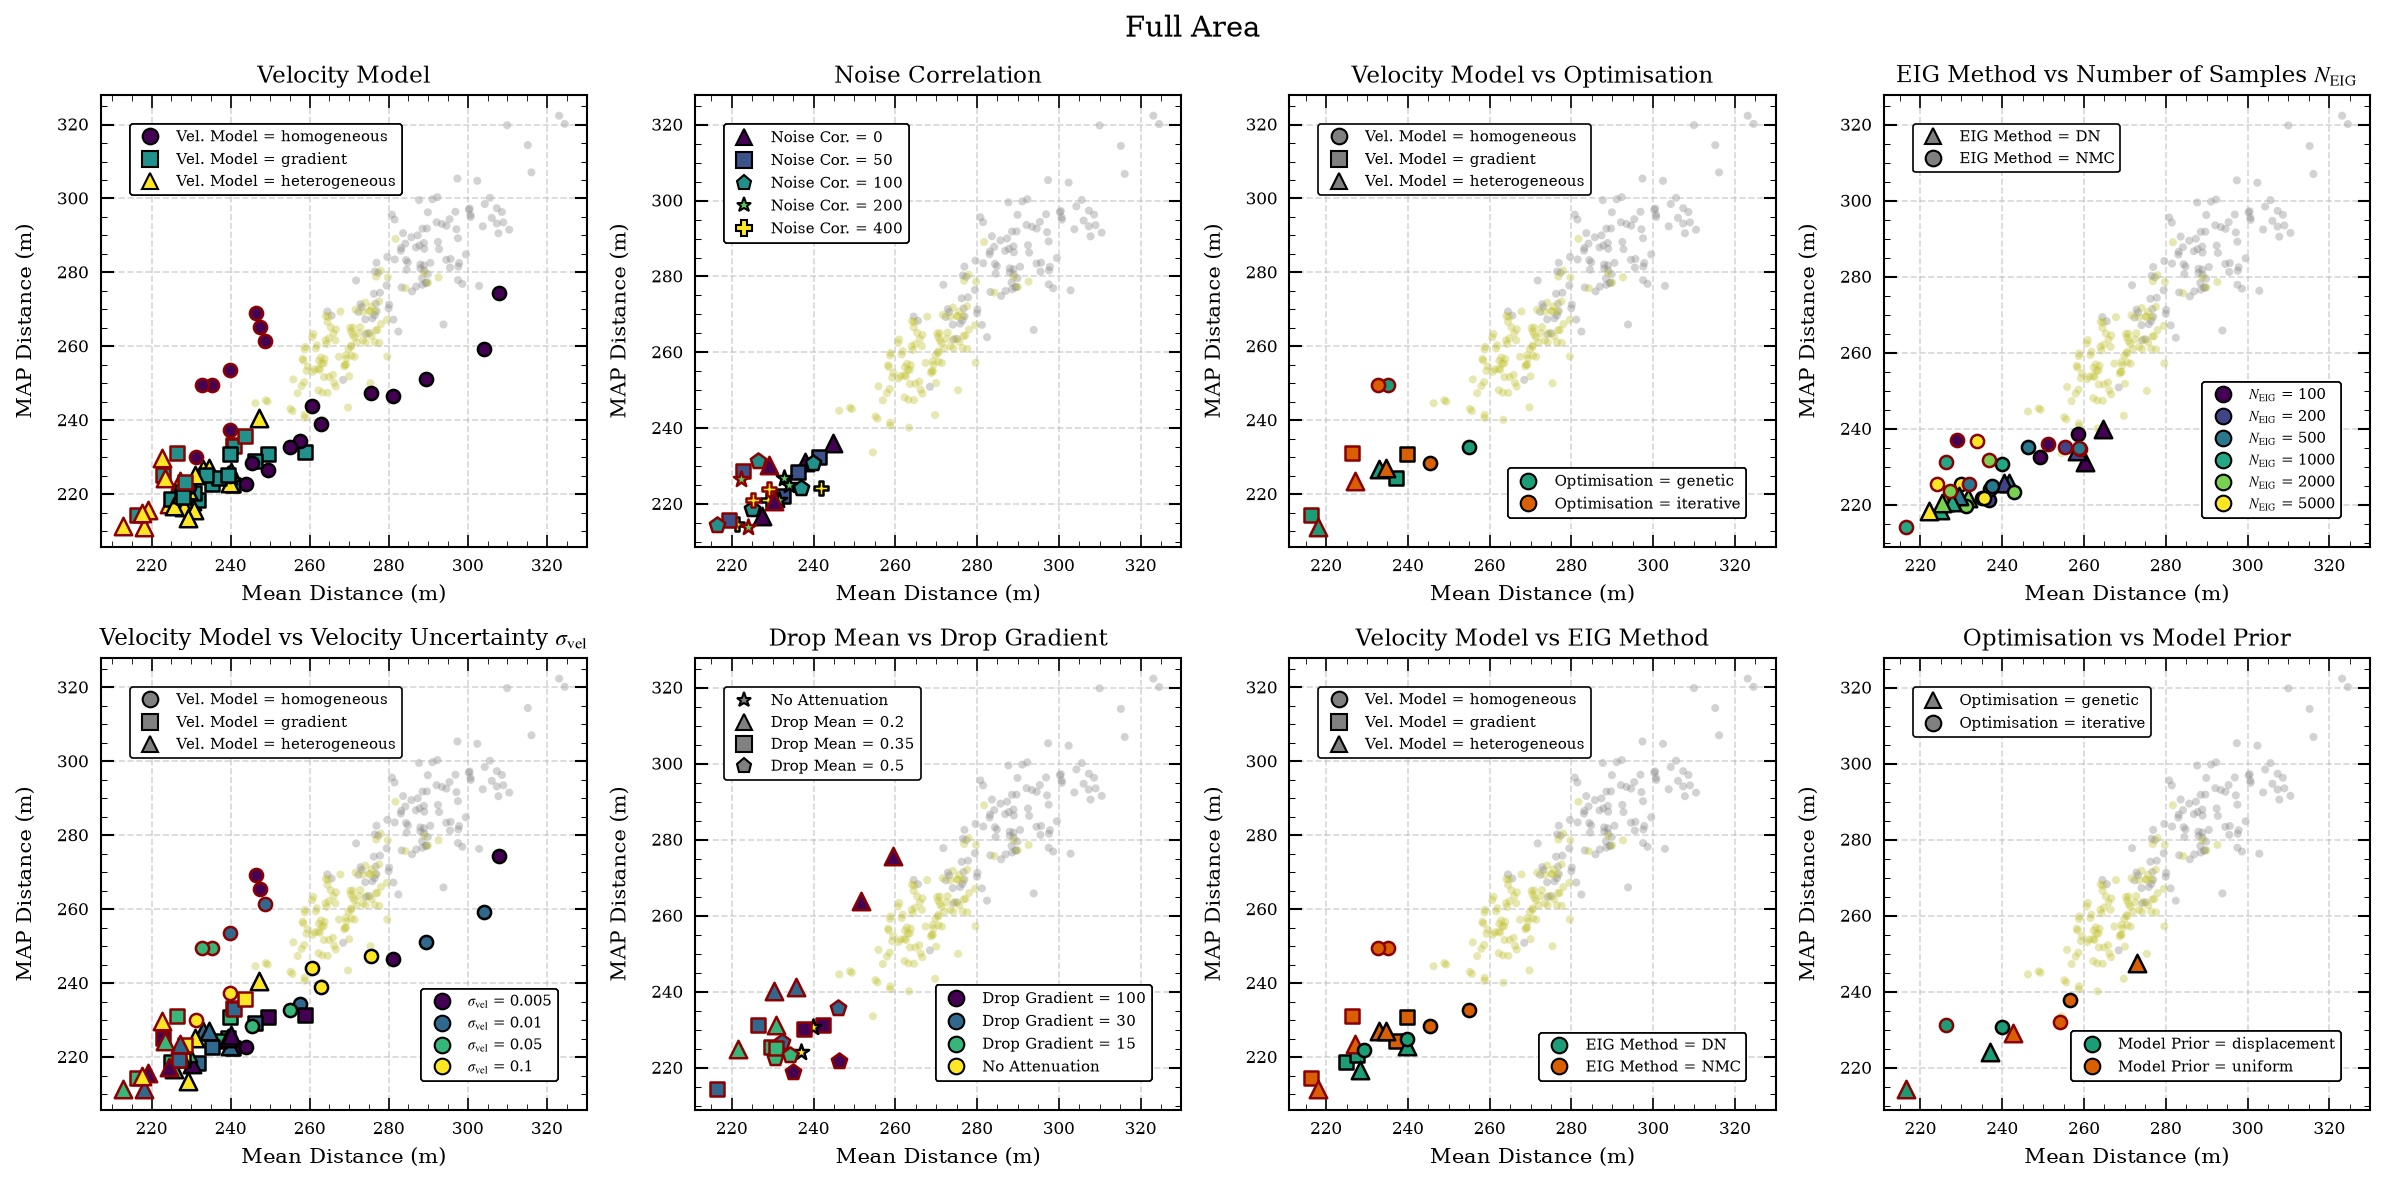

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Use design_stats for the main data (already filtered for 'genetic' and 'iterative')
stats_all = design_stats

x_quantity = 'distance_mean'
y_quantity = 'distance_map'

N_rec_min = 3
N_rec_max = 10

scenarios = [
    ("velocity_model", "velocity_model", {'set_defaults': False, 'N_rec_min': N_rec_min, 'N_rec_max': N_rec_max}),
    ("noise_correlation", "noise_correlation", {'set_defaults': False, 'N_rec_min': N_rec_min, 'N_rec_max': N_rec_max}),
    ("velocity_model", "optimisation", {'set_defaults': True, 'N_rec_min': N_rec_min, 'N_rec_max': N_rec_max}),
    ("EIG_method", "EIG_N", {'set_defaults': True, 'N_rec_min': N_rec_min, 'N_rec_max': N_rec_max}),

    ("velocity_model", "vel_sigma", {'set_defaults': False, 'N_rec_min': N_rec_min, 'N_rec_max': N_rec_max}),
    ("drop_mean", "drop_gradient",{'set_defaults': False, 'N_rec_min': N_rec_min, 'N_rec_max': N_rec_max}),
    ('velocity_model', "EIG_method", {'set_defaults': True, 'N_rec_min': N_rec_min, 'N_rec_max': N_rec_max}),
    ('optimisation', "model_prior", {'set_defaults': True, 'N_rec_min': N_rec_min, 'N_rec_max': N_rec_max}),
]

def get_color_marker_dicts(param1, param2, values1, values2):
    n1 = len(values1)
    n2 = len(values2)
    # Markers
    if n1 <= 2:
        markers = ["^", "o"]
    elif n1 <= 3:
        markers = ["^", "s", "p"]
    elif n1 <= 4:
        markers = ["*", "^", "s", "p"]
    elif n1 <= 6:
        markers = ["^", "s", "p", "*", "P", "X"]
    else:
        markers = ["o"] * n1
    marker_dict = {v: markers[i % len(markers)] for i, v in enumerate(values1)}
    # Colors
    fixed_colors = ['#1b9e77', '#d95f02']
    if n2 <= 2:
        color_dict = {v: fixed_colors[i % len(fixed_colors)] for i, v in enumerate(values2)}
    else:
        cmap = plt.get_cmap("viridis", n2)
        color_dict = {v: cmap(i) for i, v in enumerate(values2)}
    return color_dict, marker_dict

n_scenarios = len(scenarios)
n_cols = 4
n_rows = int(np.ceil(n_scenarios / n_cols))
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), squeeze=False,
)
axes = axes.flatten()

for i, (param1, param2, options) in enumerate(scenarios):
    unique_vals1 = np.sort(stats_all[param1].unique())
    unique_vals2 = np.sort(stats_all[param2].unique())
    
    if param1 == "velocity_model":
        unique_vals1 = np.array(['homogeneous', 'gradient', 'heterogeneous'])
    if param2 == "velocity_model":
        unique_vals2 = np.array(['homogeneous', 'gradient', 'heterogeneous'])
    if param2 == "drop_gradient":
        unique_vals2 = unique_vals2[::-1]
    if len(unique_vals2) < 2 or len(unique_vals1) < 1:
        axes[i].set_visible(False)
        continue
    color_dict, marker_dict = get_color_marker_dicts(param1, param2, unique_vals1, unique_vals2)
    if param1 == "velocity_model":
        marker_dict = {
            'homogeneous': 'o',
            'gradient': 's',
            'heterogeneous': '^',
        }
    plot_combinations(
        axes[i],
        data=stats_all,
        x_quantity=x_quantity,
        y_quantity=y_quantity,
        param1=param1,
        param2=param2,
        color_dict=color_dict,
        marker_dict=marker_dict,
        title=f"{title_label_map[param2]}" if param1 == param2 else f"{title_label_map[param1]} vs {title_label_map[param2]}",
        **options,
    )


# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f"Full Area", fontsize=14,
)

plt.tight_layout()

fig.savefig(f"figures/full_benchmark_{x_quantity}_{y_quantity}.png", dpi=300, bbox_inches='tight')
fig.savefig(f"figures/full_benchmark_{x_quantity}_{y_quantity}.pdf", bbox_inches='tight')

plt.show()

In [43]:
def filter_set_defaults(df, param):
    # Ensure param is a list for consistent processing
    if isinstance(param, str):
        param = [param]

    # Apply default filtering for unbiased comparison
    if "model_prior" not in param:
        df = df[df["model_prior"] == "displacement"]
    if "EIG_method" not in param:
        df = df[df["EIG_method"] == "NMC"]
    if "EIG_N" not in param:
        df = df[df["EIG_N"] == 1000]
    if "optimisation" not in param:
        df = df[df["optimisation"].isin(["genetic", "iterative"])]
    if "drop_mean" not in param:
        df = df[(df["drop_mean"] == 0.35) | (df["drop_mean"] == 0.0)]
    if "drop_gradient" not in param:
        df = df[(df["drop_gradient"] == 0.0) | (df["drop_gradient"] == 30.0)]
    if "velocity_model" not in param:
        df = df[df["velocity_model"] == "gradient"]
    if "vel_sigma" not in param:
        df = df[
            ((df["velocity_model"] == "heterogeneous") & (df["vel_sigma"] == 0.01))
            | ((df["velocity_model"].isin(["gradient", "homogeneous"])) & (df["vel_sigma"] == 0.05))
        ]
    if "noise_correlation" not in param:
        df = df[df["noise_correlation"] == 100.0]
    return df

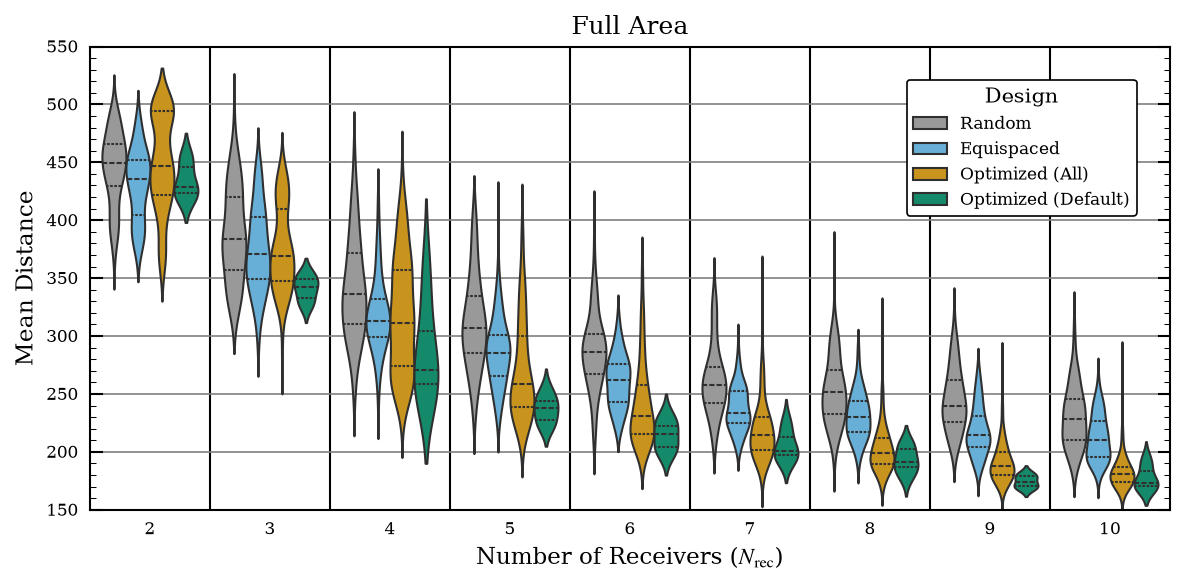

In [44]:
from copy import deepcopy
import seaborn as sns

# Deepcopy dataframes to avoid modifying the original ones
random_copy = deepcopy(random_grouped)
sobol_copy = deepcopy(sobol_grouped)

# Optimized designs with default filter applied
optimized_default = filter_set_defaults(
    deepcopy(design_stats_grouped), param=['EIG_method'])
optimized_default["Design"] = "Optimized (Default)"

# Optimized designs without default filter
optimized_all = deepcopy(design_stats_grouped)
optimized_all = optimized_all[optimized_all["EIG_N"] == 1000]
optimized_all["Design"] = "Optimized (All)"

# Add a "Design" column to random and sobol dataframes
random_copy["Design"] = "Random"
sobol_copy["Design"] = "Equispaced"

# Combine all data into one DataFrame
combined_data = pd.concat([random_copy, sobol_copy, optimized_all, optimized_default])

# Filter by receiver count
combined_data = combined_data[(combined_data["N_rec"] >= 2) & (combined_data["N_rec"] <= 10)]

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(
    data=combined_data,
    x="N_rec",
    y="distance_mean",
    hue="Design",
    split=False,
    inner="quartile",
    bw_method='silverman',
    density_norm="width",
    ax=ax,
    palette={
        "Random": "#999999",  # Light gray
        "Equispaced": "#56B4E9",   # Sky blue
        "Optimized (Default)": "#009E73",  # Orange
        "Optimized (All)":  "#E69F00",  # Green
    },
    dodge=True,
)

# Add vertical lines between N_rec groups
unique_N_rec = sorted(combined_data["N_rec"].unique())
for i in range(1, len(unique_N_rec)):
    ax.axvline((i - 0.5), color="k", linestyle="-", linewidth=1, zorder=0)

# Customize x-axis ticks
ax.set_xticks(range(len(unique_N_rec)))
ax.set_xticklabels(unique_N_rec)
ax.tick_params(axis="x", which="both", length=0)  # Hide x-ticks but show labels
ax.set_xlim(-0.5, len(unique_N_rec) - 0.5)
ax.xaxis.set_minor_locator(plt.NullLocator())  # Remove x minor ticks

# Labels and legend
ax.set_xlabel(r"Number of Receivers ($N_\mathrm{rec}$)", fontsize=11)
ax.set_ylabel("Mean Distance", fontsize=11)
ax.set_title("Full Area", fontsize=12)
ax.grid(True, axis='y', linestyle='-', color='grey')
ax.set_axisbelow(True)
ax.set_ylim(150, 550)
ax.legend(title="Design", loc="upper right", facecolor="white", fontsize=8)

fig.savefig("figures/full_benchmark_violin_distance_mean.pdf", bbox_inches='tight')
fig.savefig("figures/full_benchmark_violin_distance_mean.png", bbox_inches='tight')

plt.tight_layout()
plt.show()


In [45]:
from scipy import stats
import numpy as np

# Filter data for comparison (using the same filters as the optimized default)
optimized_data = filter_set_defaults(design_stats_grouped, param=['EIG_method'])
optimized_data = optimized_data[(optimized_data["N_rec"] >= 3) & (optimized_data["N_rec"] <= 10)]

# Random and equispaced data for same N_rec range
random_data = random_grouped[(random_grouped["N_rec"] >= 3) & (random_grouped["N_rec"] <= 10)]
equispaced_data = sobol_grouped[(sobol_grouped["N_rec"] >= 3) & (sobol_grouped["N_rec"] <= 10)]

# Calculate summary statistics after grouping by N_rec
def calculate_stats_grouped(data, metric="distance_mean"):
    # Group by N_rec and calculate mean for each group
    grouped_means = data.groupby('N_rec')[metric].mean()
    
    return {
        'count': len(grouped_means),
        'mean': grouped_means.mean(),
        'median': grouped_means.median(),
        'std': grouped_means.std(),
        'min': grouped_means.min(),
        'max': grouped_means.max()
    }

# Get statistics for each design type
opt_stats = calculate_stats_grouped(optimized_data)
random_stats = calculate_stats_grouped(random_data)
equi_stats = calculate_stats_grouped(equispaced_data)

# Calculate improvements (lower distance is better)
def calculate_improvements(opt_stats, baseline_stats, baseline_name):
    improvements = {}
    
    # Mean vs Mean improvement
    mean_abs_imp = baseline_stats['mean'] - opt_stats['mean']
    mean_pct_imp = (mean_abs_imp / baseline_stats['mean']) * 100
    
    # Median improvement
    median_abs_imp = baseline_stats['median'] - opt_stats['median']
    median_pct_imp = (median_abs_imp / baseline_stats['median']) * 100
    
    # Min baseline vs Max optimized (worst case for optimized)
    min_baseline_vs_max_opt_abs = baseline_stats['min'] - opt_stats['max']
    min_baseline_vs_max_opt_pct = (min_baseline_vs_max_opt_abs / baseline_stats['min']) * 100
    
    # Max baseline vs Min optimized (best case for optimized)
    max_baseline_vs_min_opt_abs = baseline_stats['max'] - opt_stats['min']
    max_baseline_vs_min_opt_pct = (max_baseline_vs_min_opt_abs / baseline_stats['max']) * 100
    
    return {
        f'mean_abs_vs_{baseline_name}': mean_abs_imp,
        f'mean_pct_vs_{baseline_name}': mean_pct_imp,
        f'median_abs_vs_{baseline_name}': median_abs_imp,
        f'median_pct_vs_{baseline_name}': median_pct_imp,
        f'min_{baseline_name}_vs_max_opt_abs': min_baseline_vs_max_opt_abs,
        f'min_{baseline_name}_vs_max_opt_pct': min_baseline_vs_max_opt_pct,
        f'max_{baseline_name}_vs_min_opt_abs': max_baseline_vs_min_opt_abs,
        f'max_{baseline_name}_vs_min_opt_pct': max_baseline_vs_min_opt_pct,
    }

# Calculate improvements vs both baselines
imp_vs_random = calculate_improvements(opt_stats, random_stats, 'random')
imp_vs_equi = calculate_improvements(opt_stats, equi_stats, 'equispaced')

# Statistical significance tests using grouped means
opt_grouped_means = optimized_data.groupby('N_rec')['distance_mean'].mean()
random_grouped_means = random_data.groupby('N_rec')['distance_mean'].mean()
equi_grouped_means = equispaced_data.groupby('N_rec')['distance_mean'].mean()

_, p_opt_vs_random = stats.mannwhitneyu(
    opt_grouped_means, random_grouped_means, 
    alternative='less'  # Test if optimized < random
)

_, p_opt_vs_equi = stats.mannwhitneyu(
    opt_grouped_means, equi_grouped_means, 
    alternative='less'  # Test if optimized < equispaced
)

# Create summary table
summary_data = {
    'Metric': [
        'Sample Count',
        'Mean Distance (m)',
        'Median Distance (m)', 
        'Min Distance (m)',
        'Max Distance (m)',
        'Std Dev (m)',
        '',  # Separator
        'Mean vs Mean vs Random (m)',
        'Mean vs Mean vs Random (%)',
        'Median Improvement vs Random (m)',
        'Median Improvement vs Random (%)',
        'Min Random vs Max Opt (m)',
        'Min Random vs Max Opt (%)',
        'Max Random vs Min Opt (m)',
        'Max Random vs Min Opt (%)',
        'p-value vs Random',
        '',  # Separator
        'Mean vs Mean vs Equispaced (m)',
        'Mean vs Mean vs Equispaced (%)',
        'Median Improvement vs Equispaced (m)',
        'Median Improvement vs Equispaced (%)',
        'Min Equispaced vs Max Opt (m)',
        'Min Equispaced vs Max Opt (%)',
        'Max Equispaced vs Min Opt (m)',
        'Max Equispaced vs Min Opt (%)',
        'p-value vs Equispaced'
    ],
    'Optimized': [
        opt_stats['count'],
        f"{opt_stats['mean']:.1f}",
        f"{opt_stats['median']:.1f}",
        f"{opt_stats['min']:.1f}",
        f"{opt_stats['max']:.1f}",
        f"{opt_stats['std']:.1f}",
        '',
        f"{imp_vs_random['mean_abs_vs_random']:.1f}",
        f"{imp_vs_random['mean_pct_vs_random']:.1f}%",
        f"{imp_vs_random['median_abs_vs_random']:.1f}",
        f"{imp_vs_random['median_pct_vs_random']:.1f}%", 
        f"{imp_vs_random['min_random_vs_max_opt_abs']:.1f}",
        f"{imp_vs_random['min_random_vs_max_opt_pct']:.1f}%",
        f"{imp_vs_random['max_random_vs_min_opt_abs']:.1f}",
        f"{imp_vs_random['max_random_vs_min_opt_pct']:.1f}%",
        f"{p_opt_vs_random:.2e}",
        '',
        f"{imp_vs_equi['mean_abs_vs_equispaced']:.1f}",
        f"{imp_vs_equi['mean_pct_vs_equispaced']:.1f}%",
        f"{imp_vs_equi['median_abs_vs_equispaced']:.1f}",
        f"{imp_vs_equi['median_pct_vs_equispaced']:.1f}%",
        f"{imp_vs_equi['min_equispaced_vs_max_opt_abs']:.1f}",
        f"{imp_vs_equi['min_equispaced_vs_max_opt_pct']:.1f}%",
        f"{imp_vs_equi['max_equispaced_vs_min_opt_abs']:.1f}",
        f"{imp_vs_equi['max_equispaced_vs_min_opt_pct']:.1f}%",
        f"{p_opt_vs_equi:.2e}"
    ],
    'Random': [
        random_stats['count'],
        f"{random_stats['mean']:.1f}",
        f"{random_stats['median']:.1f}",
        f"{random_stats['min']:.1f}",
        f"{random_stats['max']:.1f}",
        f"{random_stats['std']:.1f}",
        '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', ''
    ],
    'Equispaced': [
        equi_stats['count'],
        f"{equi_stats['mean']:.1f}",
        f"{equi_stats['median']:.1f}",
        f"{equi_stats['min']:.1f}",
        f"{equi_stats['max']:.1f}",
        f"{equi_stats['std']:.1f}",
        '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', ''
    ]
}

summary_df = pd.DataFrame(summary_data)
print("Performance Comparison Summary (3-10 receivers)")
print("=" * 60)
print(summary_df.to_string(index=False))

# Key takeaways
print("\n" + "="*60)
print("KEY TAKEAWAYS:")
print("="*60)
print(f"• Optimized mean is {imp_vs_random['mean_pct_vs_random']:.1f}% better than random mean")
print(f"• Optimized mean is {imp_vs_equi['mean_pct_vs_equispaced']:.1f}% better than equispaced mean")
print(f"• Best optimized (min) is {imp_vs_equi['max_equispaced_vs_min_opt_pct']:.1f}% better than worst equispaced (max)")
print(f"• Worst optimized (max) vs best baseline (min): Random {imp_vs_random['min_random_vs_max_opt_pct']:.1f}%, Equispaced {imp_vs_equi['min_equispaced_vs_max_opt_pct']:.1f}%")
print(f"• All differences are statistically significant (p < 0.001)")


Performance Comparison Summary (3-10 receivers)
                              Metric Optimized Random Equispaced
                        Sample Count         8      8          8
                   Mean Distance (m)     228.7  290.2      267.8
                 Median Distance (m)     209.9  274.9      249.6
                    Min Distance (m)     174.6  230.6      212.5
                    Max Distance (m)     341.0  388.0      374.3
                         Std Dev (m)      58.1   53.9       56.1
                                                                
          Mean vs Mean vs Random (m)      61.5                  
          Mean vs Mean vs Random (%)     21.2%                  
    Median Improvement vs Random (m)      65.0                  
    Median Improvement vs Random (%)     23.6%                  
           Min Random vs Max Opt (m)    -110.5                  
           Min Random vs Max Opt (%)    -47.9%                  
           Max Random vs Min Opt (m)     2

In [46]:
# import seaborn as sns

# import matplotlib.pyplot as plt

# # Deepcopy dataframes to avoid modifying the original ones
# random_copy = deepcopy(random_grouped)
# sobol_copy = deepcopy(sobol_grouped)

# # Optimized designs with default filter applied
# optimized_default = filter_set_defaults(
#     deepcopy(design_stats_grouped), param=['EIG_method'])
# optimized_default["Design"] = "Optimized (Default)"

# # Optimized designs without default filter
# optimized_all = deepcopy(design_stats_grouped)
# optimized_all = optimized_all[optimized_all["EIG_N"] == 1000]
# optimized_all["Design"] = "Optimized (All)"

# # Add a "Design" column to random and sobol dataframes
# random_copy["Design"] = "Random"
# sobol_copy["Design"] = "Sobol"

# # Combine all data into one DataFrame
# combined_data = pd.concat([random_copy, sobol_copy, optimized_default, optimized_all])

# # Filter by receiver count
# combined_data = combined_data[(combined_data["N_rec"] >= 3) & (combined_data["N_rec"] <= 10)]

# # Plot
# fig, ax = plt.subplots(figsize=(10, 6))
# sns.stripplot(
#     data=combined_data,
#     x="N_rec",
#     y="distance_mean",
#     hue="Design",
#     dodge=True,
#     jitter=True,
#     alpha=0.7,
#     palette={
#         "Random": "grey",
#         "Sobol": "olive",
#         "Optimized (Default)": "red",
#         "Optimized (All)": "blue",
#     },
#     ax=ax,
# )

# # Labels and legend
# ax.set_xlabel("Number of Receivers (N_rec)")
# ax.set_ylabel("Mean Distance")
# ax.set_title("Mean Distance by Receiver Number")
# ax.grid(True, axis='y', linestyle='-', color='grey')
# ax.set_axisbelow(True)
# ax.legend(title="Design", loc="upper right", facecolor="white", fontsize=8)

# plt.tight_layout()
# plt.show()

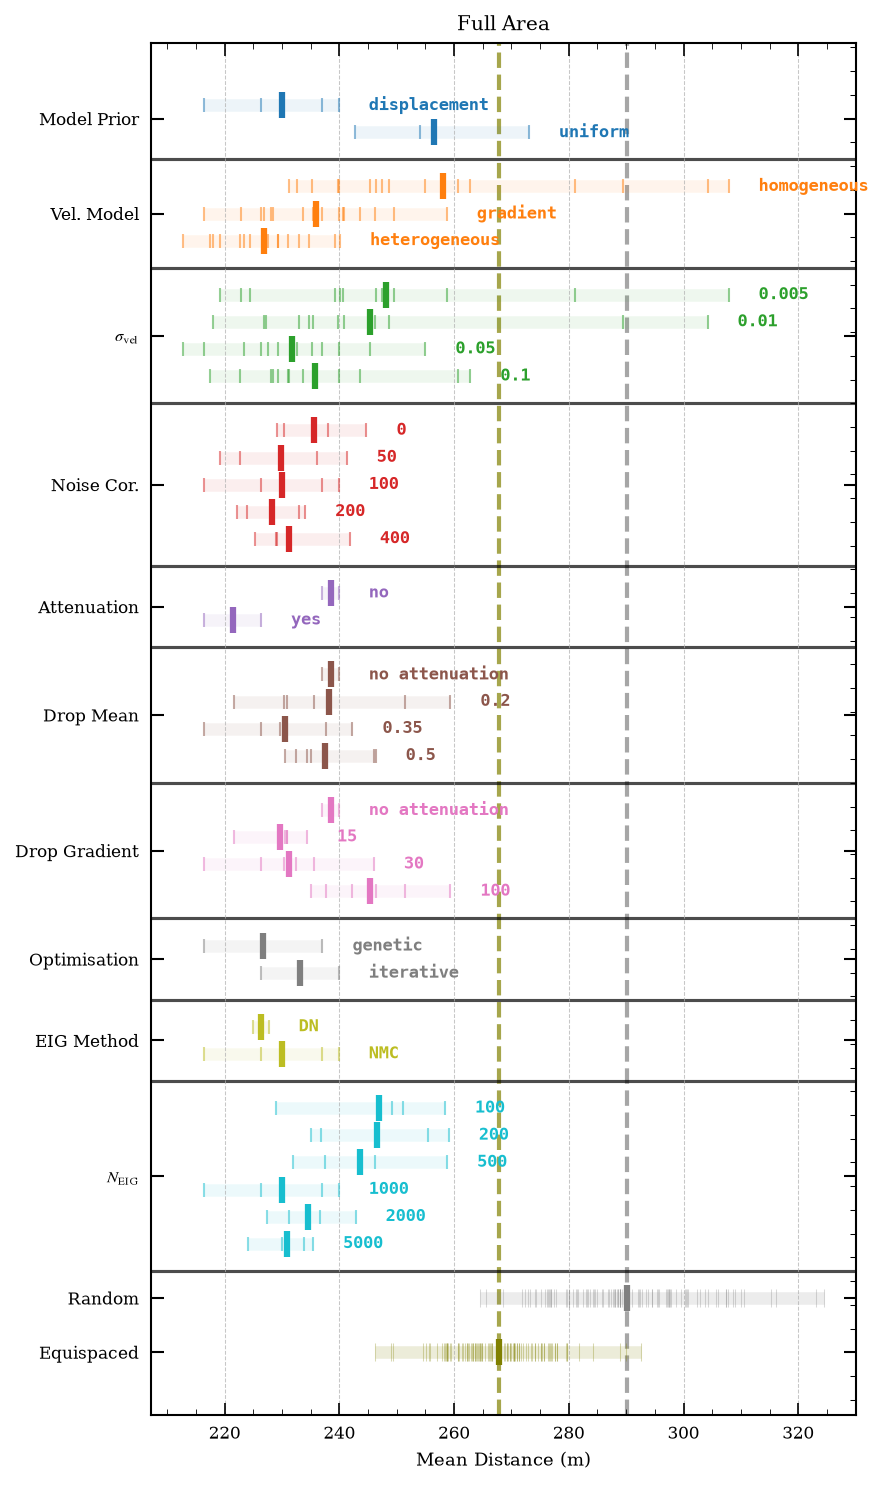

In [47]:
def plot_param_summary(
    ax,
    data,
    param_list,
    metric="distance_mean",
    N_rec_min=3,
    N_rec_max=10,
    set_defaults=True,
):

    ypos = 0
    colors = plt.get_cmap("tab10")
    ytick_positions = []
    ytick_labels = []
    
    for idx, param in enumerate(param_list):
        df = data[(data["N_rec"] >= N_rec_min) & (data["N_rec"] <= N_rec_max)]
        if param in ["velocity_model", "vel_sigma",]:
            df = filter_set_defaults(df, ["velocity_model", "vel_sigma",])
        elif param in ["drop_mean", "drop_gradient"]:
            df = filter_set_defaults(df, ["drop_mean", "drop_gradient"])
        else:
            df = filter_set_defaults(df, param)
        grouped = df.groupby(scen_columns)[metric].mean().reset_index()
        
        if param == "velocity_model":
            order = ["homogeneous", "gradient", "heterogeneous"]
            grouped[param] = pd.Categorical(grouped[param], categories=order, ordered=True)
            grouped = grouped.sort_values(param)
        grouped_param = grouped.groupby(param, observed=True)[metric]
        means = grouped_param.mean()
        mins = grouped_param.min()
        maxs = grouped_param.max()
                        
        # Calculate y positions for this parameter's values
        n_values = len(means)
        y_pos = ypos + np.arange(n_values)
        
        # Store the center position for y-tick
        ytick_positions.append(ypos+(n_values-1) / 2)
        ytick_labels.append(legend_label_map.get(param, param))
        
        # Update ypos for next parameter
        ypos += n_values + 1
        
        # Scale area of categories by number of members
        sizes = grouped_param.size()
        
        # Plot min/max as more transparent
        ax.hlines(y_pos, mins, maxs, color=colors(idx), linewidth=6, alpha=0.08, zorder=1)
        # Plot every sample as small vertical line
        for i, param_val in enumerate(means.index):
            samples = grouped[grouped[param] == param_val][metric]
            # ax.vlines(samples, y_pos[i] - 0.08, y_pos[i] + 0.08, color=colors(idx), alpha=0.5, linewidth=1, zorder=2)
            ax.scatter(
                samples,
                [y_pos[i]] * len(samples),
                color=colors(idx),
                marker="|",
                s=40,
                linewidth=1.0,
                alpha=0.5,
                zorder=2,
            )
            
        # Plot mean as bigger plus marker with scaled sizes
        label = legend_label_map.get(param, param)
        ax.scatter(means, y_pos, color=colors(idx), marker="|", s=150, linewidth=3, zorder=10, label=label, alpha=1.0)
        for i, (max_val, param_val) in enumerate(zip(maxs, means.index)):
            # Custom label for drop_mean/drop_gradient == 0
            if param in ("drop_mean", "drop_gradient") and (param_val == 0 or param_val == 0.0):
                display_val = "no attenuation"
            else:
                display_val = param_val
            ax.text(
                max_val,
                y_pos[i],
                f"   {display_val}",
                va="center",
                ha="left",
                fontsize=8,
                color=colors(idx),
                fontweight="bold",
                fontfamily="monospace"
            )
                
        # add separator line between parameters
        ax.axhline(ypos - 1, color="black", linewidth=1.5, linestyle="-", alpha=0.7, zorder=0)
    
    # Add reference rows for random and sobol designs
    for ref_idx, (ref_name, ref_df) in enumerate(
        [("Random", random_grouped), ("Equispaced", sobol_grouped)]
    ):
        ref_vals = ref_df[
            (ref_df["N_rec"] >= N_rec_min) & (ref_df["N_rec"] <= N_rec_max)
        ]
        ref_vals = ref_vals.groupby("design_index")[metric].mean().reset_index(drop=True)
        
        mean_val = ref_vals.mean()
        min_val = ref_vals.min()
        max_val = ref_vals.max()
        y_pos_ref = ypos + 2*ref_idx
        ytick_positions.append(y_pos_ref)
        ytick_labels.append(ref_name)
        
        color = "grey" if ref_name == "Random" else "olive"
        ax.hlines(y_pos_ref, min_val, max_val, color=color, linewidth=6, alpha=0.15, zorder=1)
        # Plot every sample as small vertical line
        # ax.vlines(ref_vals, y_pos_ref - 0.08, y_pos_ref + 0.08, color=color, alpha=0.1, linewidth=1, zorder=2)
        
        ax.scatter(
            ref_vals,
            [y_pos_ref] * len(ref_vals),
            color=color,
            marker="|",
            s=80,
            linewidth=0.5, alpha=0.3,
            zorder=2,
        )
        ax.axvline(mean_val, color=color, linestyle="--", linewidth=2.0, alpha=0.7, zorder=-3)       
        
        # Plot mean as bigger plus marker
        ax.scatter(mean_val, y_pos_ref, color=color, marker="|", s=150, linewidth=3, zorder=10, label=ref_name)
    
    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(ytick_labels)
    ax.set_xlabel(quantity_labels.get(metric, metric))
    ax.set_title("Full Area")
    ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.invert_yaxis()
    ax.tick_params(axis="y", which="minor", left=False)  # Remove y-axis minor ticks
    plt.tight_layout()
    

# Usage:
param_list = [
    "model_prior",
    "velocity_model",
    "vel_sigma",
    "noise_correlation",
    "attenuation",
    "drop_mean",
    "drop_gradient",
    "optimisation",
    "EIG_method",
    "EIG_N",
]
metric = "distance_mean"
N_rec_min = 3
N_rec_max = 10

fig, ax = plt.subplots(figsize=(6, 1.0 * len(param_list)))
plot_param_summary(
    ax, design_stats, param_list, metric, N_rec_min, N_rec_max, set_defaults=True)

# fig.savefig(
#     "figures/full_benchmark_param_summary_distance_mean.png",
#     dpi=300, bbox_inches='tight'
# )
# fig.savefig(
#     "figures/full_benchmark_param_summary_distance_mean.pdf",
#     bbox_inches='tight'
# )

plt.show()

In [48]:
design_stats.columns

Index(['study_area', 'model_prior', 'velocity_model', 'vel_sigma',
       'noise_correlation', 'drop_mean', 'drop_gradient', 'attenuation',
       'optimisation', 'EIG_method', 'EIG_N', 'N_rec', 'mean_x', 'mean_y',
       'mean_z', 'std_x', 'std_y', 'std_z', 'std', 'distance_mean',
       'distance_map', 'p_posterior', 'posterior_entropy',
       'posterior_information', 'prior_entropy', 'prior_information'],
      dtype='str')

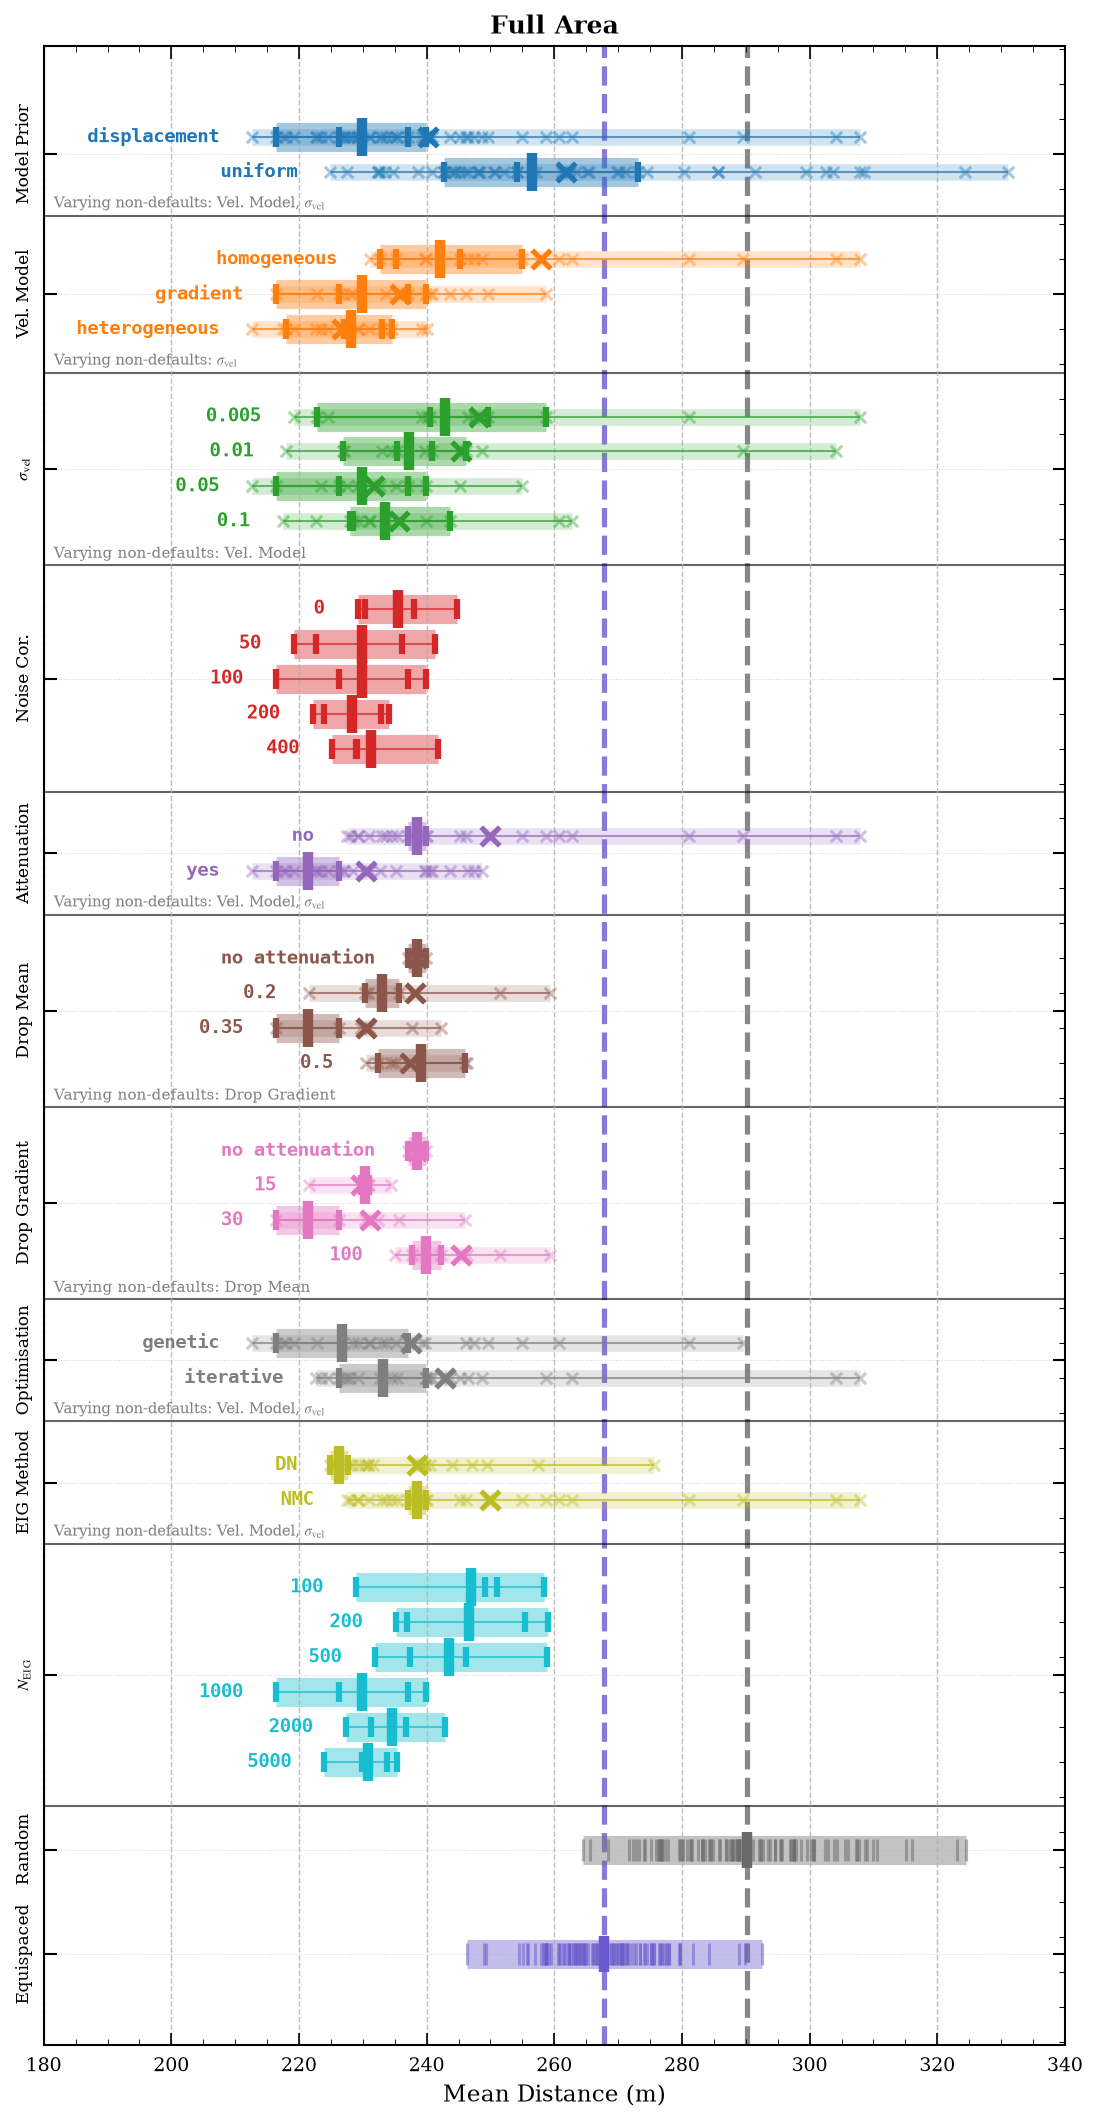

In [49]:
from matplotlib.lines import Line2D

def plot_param_summary(
    ax,
    data,
    param_list,
    metric="distance_mean",
    N_rec_min=3,
    N_rec_max=10,
):

    ypos = 0
    colors = plt.get_cmap("tab10")
    ytick_positions = []
    ytick_labels = []
    
    
    for idx, param in enumerate(param_list):
        df = data[(data["N_rec"] >= N_rec_min) & (data["N_rec"] <= N_rec_max)]
        
        free_params_list = []

        if param in ["model_prior",]:
            free_params_list = ["velocity_model", "vel_sigma", "model_prior",] + [param,]
            df_all = filter_set_defaults(df, free_params_list)
            df_default = filter_set_defaults(df, param)
        
        elif param in ["velocity_model", "attenuation", "optimisation"]:
            free_params_list = ["velocity_model", "vel_sigma", ] + [param,]
            df_all = filter_set_defaults(df, free_params_list)
            df_default = filter_set_defaults(df, param)
        elif param in ["EIG_method"]:
            df = df[df["attenuation"] == "no"]
            free_params_list = ["velocity_model", "vel_sigma", "EIG_method"] + [param,]
            df_all = filter_set_defaults(df, free_params_list)
            df_default = filter_set_defaults(df, param)
        
        elif param in ["vel_sigma",]:
            free_params_list = ["vel_sigma", "velocity_model"]
            df_all = filter_set_defaults(df, free_params_list)
            df_default = filter_set_defaults(df, param)
        elif param in ["drop_mean", "drop_gradient"]:
            free_params_list = ["drop_mean", "drop_gradient"]
            df_all = filter_set_defaults(df, free_params_list)
            df_default = filter_set_defaults(df, param)
        else:
            df_all = None
            df_default = filter_set_defaults(df, param)
        
        # Determine the dataframes to plot for the current parameter
        dfs_to_plot = []
        if df_all is not None:
            dfs_to_plot.append(df_all)
        dfs_to_plot.append(df_default)

        # Group and get stats for the first dataframe to determine y-positions
        grouped_base = dfs_to_plot[-1].groupby(scen_columns)[metric].mean().reset_index()
        if param == "velocity_model":
            order = ["homogeneous", "gradient", "heterogeneous"]
            grouped_base[param] = pd.Categorical(grouped_base[param], categories=order, ordered=True)
            grouped_base = grouped_base.sort_values(param)
        
        n_values = len(grouped_base.groupby(param, observed=True))
        
        # Store the center position for y-tick
        center_ypos = ypos + (n_values - 1) / 2
        ytick_positions.append(center_ypos)
        ytick_labels.append(legend_label_map.get(param, param))

        # Add text for other varying parameters
        if df_all is not None:
            other_params = [p for p in free_params_list if p != param]
            if other_params:
                # Use legend_label_map for prettier names
                other_params_labels = [legend_label_map.get(p, p) for p in other_params]
                # Place text at the bottom of the group
                ax.text(
                    0.01, ypos + n_values - 0.3,
                    f"Varying non-defaults: {', '.join(other_params_labels)}",
                    va='top', ha='left',
                    fontsize=7, color='gray',
                    transform=ax.get_yaxis_transform(),
                )


        # Get the min values for text positioning
        # Use df_all if available, otherwise df_default
        df_for_text_pos = df_all if df_all is not None else df_default
        grouped_text_pos = df_for_text_pos.groupby(scen_columns)[metric].mean().reset_index()
        if param == "velocity_model":
            order = ["homogeneous", "gradient", "heterogeneous"]
            grouped_text_pos[param] = pd.Categorical(grouped_text_pos[param], categories=order, ordered=True)
            grouped_text_pos = grouped_text_pos.sort_values(param)
        text_pos_mins = grouped_text_pos.groupby(param, observed=True)[metric].min()


        # Plot each dataframe (df_all and/or df_default)
        for i, df_plot in enumerate(dfs_to_plot):
            is_default_df = (i == len(dfs_to_plot) - 1)
            
            grouped = df_plot.groupby(scen_columns)[metric].mean().reset_index()
            
            if param == "velocity_model":
                order = ["homogeneous", "gradient", "heterogeneous"]
                grouped[param] = pd.Categorical(grouped[param], categories=order, ordered=True)
                grouped = grouped.sort_values(param)
            
            grouped_param = grouped.groupby(param, observed=True)[metric]
            means = grouped_param.mean()
            mins = grouped_param.min()
            maxs = grouped_param.max()
            
            # Calculate y positions for this parameter's values
            y_pos = ypos + np.arange(len(means))
            
            # Increased opacity (alpha) for better visibility
            ax.hlines(y_pos, mins, maxs, color=colors(idx), linewidth=14 if is_default_df else 8, 
                     alpha=0.4 if is_default_df else 0.2, zorder=1)
            
            # Add borders to the filled areas for better distinction
            ax.hlines(y_pos, mins, maxs, color=colors(idx), linewidth=1, alpha=0.7, zorder=2)
            
            # Plot individual samples
            for j, param_val in enumerate(means.index):
                samples = grouped[grouped[param] == param_val][metric]
                ax.scatter(
                    samples,
                    [y_pos[j]] * len(samples),
                    color=colors(idx),
                    marker="|" if is_default_df else "x",
                    s=100 if is_default_df else 30,  # Increased size
                    linewidth=3.0 if is_default_df else 1.5,
                    alpha=1.0 if is_default_df else 0.4,  # Increased opacity
                    zorder=3,
                )
            
            # Plot mean marker - increased size and linewidth
            ax.scatter(means, y_pos, color=colors(idx), marker="|" if is_default_df else "x", 
                      s=350 if is_default_df else 80, linewidth=5 if is_default_df else 2.5, 
                      zorder=10, alpha=1.0)
            
            # Add text labels only for the default (last) dataframe
            if is_default_df:
                for j, (min_val, param_val) in enumerate(zip(text_pos_mins, means.index)):
                    if param in ("drop_mean", "drop_gradient") and (param_val == 0 or param_val == 0.0):
                        display_val = "no attenuation"
                    else:
                        display_val = param_val
                    ax.text(
                        min_val,
                        y_pos[j],
                        f"{display_val}   ",
                        va="center",
                        ha="right",
                        fontsize=9,  # Increased font size
                        color=colors(idx),
                        fontweight="bold",
                        fontfamily="monospace"
                    )

        # Update ypos for the next parameter group, adding more padding
        ypos += n_values + 1.5
        
        # Add separator line between parameters
        if idx < len(param_list) - 1:
            ax.axhline(ypos - 1.25, color="black", linewidth=1.0, linestyle="-", alpha=0.6, zorder=0)

    # add line between parameters and random baseline
    ax.axhline(ypos - 1.25, color="black", linewidth=1.0, linestyle="-", alpha=0.6, zorder=0)

    # Add reference rows for random and sobol designs with increased visibility
    for ref_idx, (ref_name, ref_df) in enumerate(
        [("Random", random_grouped), ("Equispaced", sobol_grouped)]
    ):
        ref_vals = ref_df[
            (ref_df["N_rec"] >= N_rec_min) & (ref_df["N_rec"] <= N_rec_max)
        ]
        ref_vals = ref_vals.groupby("design_index")[metric].mean().reset_index(drop=True)
        
        mean_val = ref_vals.mean()
        min_val = ref_vals.min()
        max_val = ref_vals.max()
        y_pos_ref = ypos + 3*ref_idx
        ytick_positions.append(y_pos_ref)
        ytick_labels.append(ref_name)
        
        # More distinctive colors for reference lines
        color = "dimgray" if ref_name == "Random" else "slateblue"
        ax.hlines(y_pos_ref, min_val, max_val, color=color, linewidth=14, alpha=0.4, zorder=1)
        
        ax.scatter(
            ref_vals,
            [y_pos_ref] * len(ref_vals),
            color=color,
            marker="|",
            s=120,
            linewidth=1.5, alpha=0.5,
            zorder=2,
        )
        # More visible reference line
        ax.axvline(mean_val, color=color, linestyle='--', linewidth=2.5, alpha=0.8, zorder=-3)       
        
        # Plot mean as bigger plus marker
        ax.scatter(mean_val, y_pos_ref, color=color, marker="|", s=300, linewidth=5, zorder=10, label=ref_name)
    
    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(
        ytick_labels, fontsize=8, rotation=90,
        va='center', ha='right', 
    )
    
    ax.set_xlabel(quantity_labels.get(metric, metric), fontsize=11)
    ax.set_title("Full Area", fontsize=12, fontweight='bold')
    ax.grid(True, axis="x", linestyle="--", linewidth=0.7, alpha=0.8)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.5)  # Added y grid for better reading
    ax.invert_yaxis()
    ax.tick_params(axis="y", which="minor", left=False)
    ax.tick_params(axis='x', labelsize=9)
    plt.tight_layout()
    

# Usage:
param_list = [
    "model_prior",
    "velocity_model",
    "vel_sigma",
    "noise_correlation",
    "attenuation",
    "drop_mean",
    "drop_gradient",
    "optimisation",
    "EIG_method",
    "EIG_N",
]
metric = "distance_mean"
N_rec_min = 3
N_rec_max = 10

# Increase figure height for better padding
fig, ax = plt.subplots(figsize=(8, 1.425 * len(param_list)))
plot_param_summary(
    ax, design_stats, param_list, metric, N_rec_min, N_rec_max)
ax.set_xlim(180, 340)

fig.savefig(
    "figures/full_benchmark_param_summary_distance_mean.png",
    dpi=300, bbox_inches='tight'
)
fig.savefig(
    "figures/full_benchmark_param_summary_distance_mean.pdf",
    bbox_inches='tight'
)

plt.show()

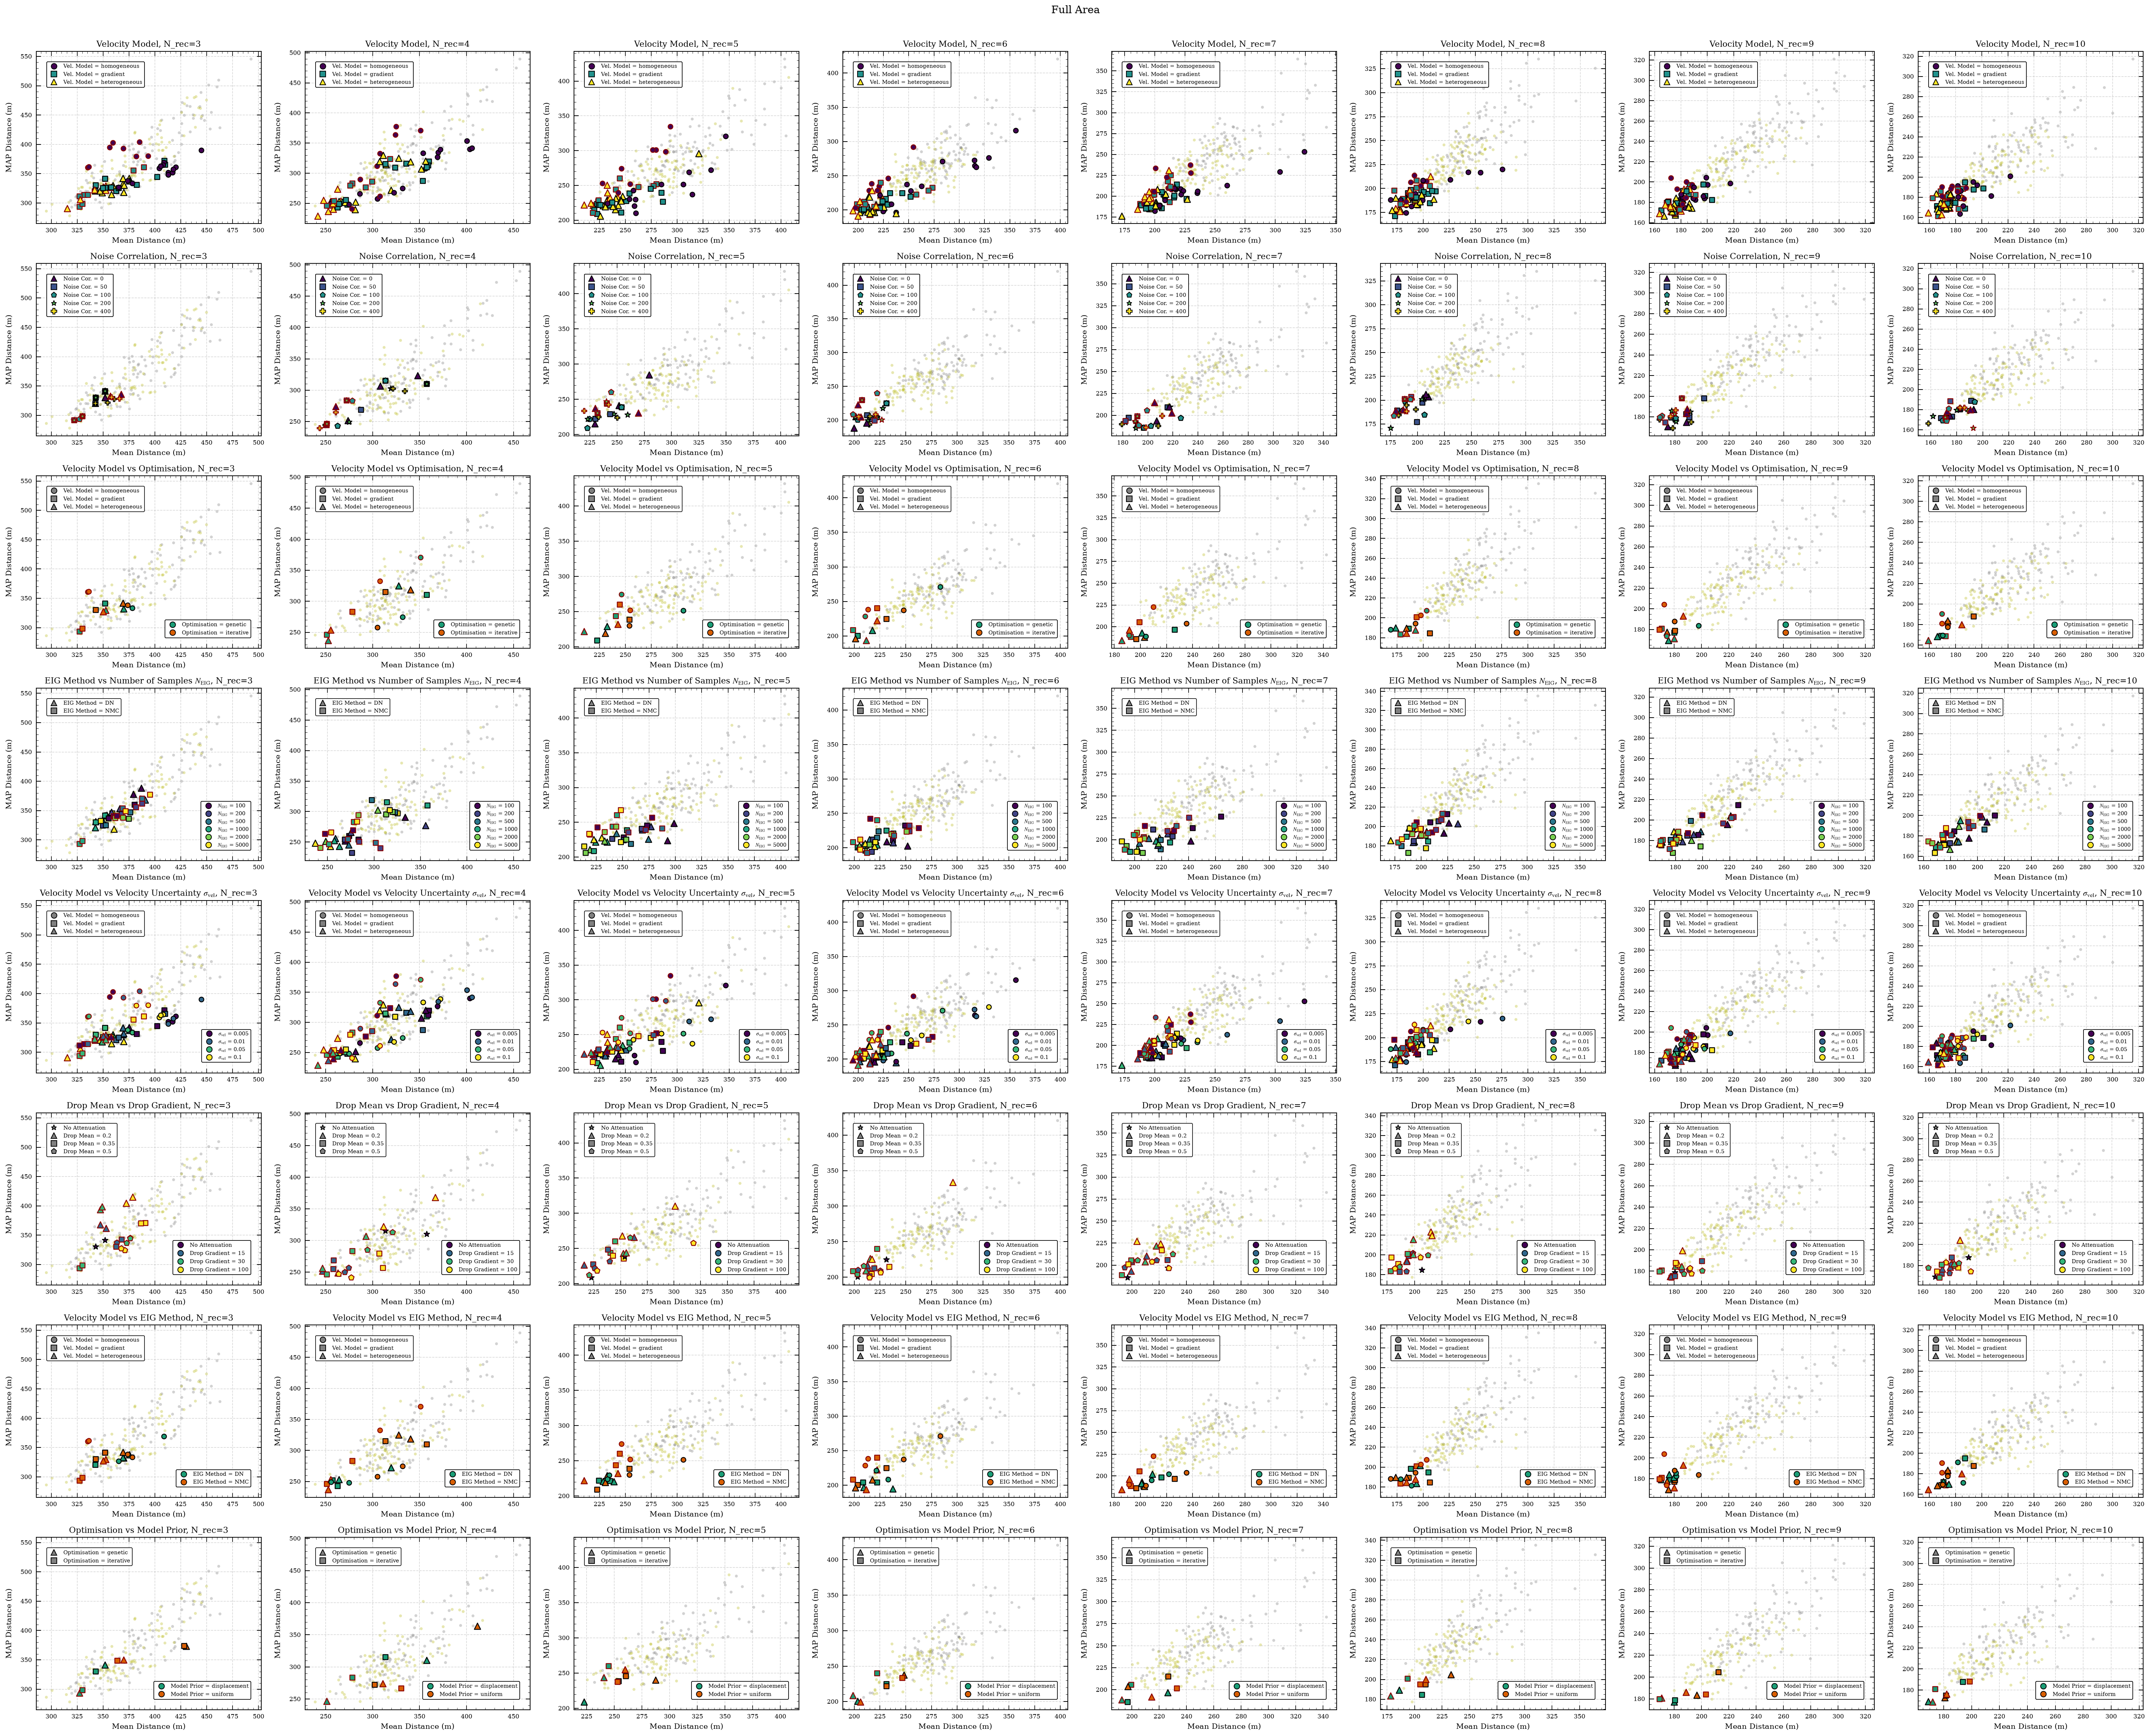

In [50]:
import numpy as np
import matplotlib.pyplot as plt

stats_all = design_stats

x_quantity = 'distance_mean'
y_quantity = 'distance_map'

scenarios = {
    ("velocity_model", "velocity_model"): {'set_defaults': False},
    ("noise_correlation", "noise_correlation"): {'set_defaults': False},
    ("velocity_model", "optimisation"): {'set_defaults': True},
    ("EIG_method", "EIG_N"): {'set_defaults': True},
    ("velocity_model", "vel_sigma"): {'set_defaults': False},
    ("drop_mean", "drop_gradient"): {'set_defaults': False},
    ('velocity_model', "EIG_method"): {'set_defaults': True},
    ('optimisation', "model_prior"): {'set_defaults': True},
}

def get_color_marker_dicts(param1, param2, values1, values2):
    n1 = len(values1)
    n2 = len(values2)
    if n1 <= 3:
        markers = ["^", "s", "p"]
    elif n1 <= 4:
        markers = ["*", "^", "s", "p"]
    elif n1 <= 6:
        markers = ["^", "s", "p", "*", "P", "X"]
    else:
        markers = ["o"] * n1
    marker_dict = {v: markers[i % len(markers)] for i, v in enumerate(values1)}
    fixed_colors = ['#1b9e77', '#d95f02']
    if n2 <= 2:
        color_dict = {v: fixed_colors[i % len(fixed_colors)] for i, v in enumerate(values2)}
    else:
        cmap = plt.get_cmap("viridis", n2)
        color_dict = {v: cmap(i) for i, v in enumerate(values2)}
    return color_dict, marker_dict

N_rec_min = 3
N_rec_max = 10
n_scenarios = len(scenarios)
n_N_rec = N_rec_max - N_rec_min + 1

fig, axes = plt.subplots(
    n_scenarios, n_N_rec, figsize=(5 * n_N_rec, 4 * n_scenarios), squeeze=False,
    # sharex='col', sharey='col'
)

for row, (param1, param2) in enumerate(scenarios):
    unique_vals1 = np.sort(stats_all[param1].unique())
    unique_vals2 = np.sort(stats_all[param2].unique())
    if param1 == "velocity_model":
        unique_vals1 = np.array(['homogeneous', 'gradient', 'heterogeneous'])
    if param2 == "velocity_model":
        unique_vals2 = np.array(['homogeneous', 'gradient', 'heterogeneous'])
    if param2 == "drop_mean":
        unique_vals1 = unique_vals1[::-1]
    color_dict, marker_dict = get_color_marker_dicts(param1, param2, unique_vals1, unique_vals2)
    if param1 == "velocity_model":
        marker_dict = {
            'homogeneous': 'o',
            'gradient': 's',
            'heterogeneous': '^',
        }
    for col, N_rec in enumerate(range(N_rec_min, N_rec_max + 1)):
        ax = axes[row, col]
        plot_combinations(
            ax,
            data=stats_all[stats_all['N_rec'] == N_rec],
            x_quantity=x_quantity,
            y_quantity=y_quantity,
            param1=param1,
            param2=param2,
            color_dict=color_dict,
            marker_dict=marker_dict,
            title=f"{title_label_map[param1]} vs {title_label_map[param2]}, N_rec={N_rec}" if param1 != param2 else f"{title_label_map[param1]}, N_rec={N_rec}",
            N_rec_min=N_rec,
            N_rec_max=N_rec,
            **scenarios[(param1, param2)],
        )

title_label_map

fig.suptitle("Full Area", fontsize=14,  y=1.005)
plt.tight_layout()

fig.savefig(f"figures/full_benchmark_detailed_{x_quantity}_{y_quantity}.png", dpi=150)
fig.savefig(f"figures/full_benchmark_detailed_{x_quantity}_{y_quantity}.pdf", dpi=150)

plt.show()


In [51]:
# quantity_labels = {
#     'distance_mean': 'Mean Distance (m)',
#     'distance_map': 'MAP Distance (m)',
#     'posterior_entropy': 'Posterior Entropy (nats)',
#     'EIG': 'Expected Information Gain (nats)',
#     'N_rec': 'Number of Receivers',
# }

# def plot_single_quantity(
#     ax,
#     data,
#     x_quantity, 
#     param1,
#     param2=None,
#     color_dict=None,
#     marker_dict=None,
#     random_grouped=None,
#     sobol_grouped=None,
#     background_alpha=0.35,
#     title=None,
#     attenuation=None,
#     set_defaults=True,
#     select_matching=False,
#     N_rec_min=2,
#     N_rec_max=10
# ):
#     """
#     Plot a single quantity for combinations of parameters on a horizontal line (y=0).
#     Also plot histograms of random and sobol in the bottom 20% of the plot.
#     """
#     import pandas as pd
#     from matplotlib.lines import Line2D
#     import numpy as np

#     # Take mean over N_rec from min to max
#     data = data[(data['N_rec'] >= N_rec_min) & (data['N_rec'] <= N_rec_max)]
#     data = data.groupby(scen_columns).mean().reset_index()
#     data = data.reset_index(drop=True)
        
#     # Filtering for unbiased comparison (same as before)
#     if set_defaults:
#         if 'model_prior' not in [param1, param2]:
#             data = data[data['model_prior'] == 'displacement']
#         if 'EIG_method' not in [param1, param2]:
#             data = data[data['EIG_method'] == 'NMC']
#         if 'EIG_N' not in [param1, param2]:
#             data = data[data['EIG_N'] == 1000]
#         if 'optimisation' not in [param1, param2]:
#             data = data[data['optimisation'].isin(['iterative', 'genetic'])]
#         if 'drop_mean' not in [param1, param2]:
#             data = data[(data['drop_mean'] == 0.35) | (data['drop_mean'] == 0.0)]
#         if 'drop_gradient' not in [param1, param2]:
#             data = data[(data['drop_gradient'] == 0.0) | (data['drop_gradient'] == -15.0)]
#         if 'velocity_model' not in [param1, param2]:
#             data = data[data['velocity_model'] == 'gradient']
#         if 'vel_sigma' not in [param1, param2]:
#             data = data[
#                 ((data['velocity_model'] == 'heterogeneous') & (data['vel_sigma'] == 0.01))
#                 | ((data['velocity_model'].isin(['gradient', 'homogeneous'])) & (data['vel_sigma'] == 0.05))
#             ]
#         if 'noise_correlation' not in [param1, param2]:
#             data = data[data['noise_correlation'] == 100.0]

#     param_cols = [param1] + ([param2] if param2 and param1 != param2 else [])
#     other_cols = [c for c in ['model_prior', 'velocity_model', 'vel_sigma', 'noise_correlation',
#                               'drop_mean', 'drop_gradient', 'optimisation', 'EIG_method', 'EIG_N']
#                   if c not in param_cols]

#     if attenuation is not None:
#         if attenuation:
#             data = data[data['drop_mean'] > 0.0]
#         else:
#             data = data[data['drop_mean'] == 0.0]

#     if select_matching:
#         grouped = data.groupby(other_cols)
#         valid_indices = []
#         for name, group in grouped:
#             param_combinations = data[param_cols].drop_duplicates()
#             group_combinations = group[param_cols].drop_duplicates()
#             if len(group_combinations) == len(param_combinations):
#                 valid_indices.extend(group.index.tolist())
#         valid_indices = pd.Index(valid_indices)
#         data = data.loc[valid_indices]

#     legend_label_map = {
#         'EIG_method': 'EIG Method',
#         'EIG_N': r'$N_\text{EIG}$',
#         'velocity_model': 'Vel. Model',
#         'drop_mean': r'Drop Mean',
#         'drop_gradient': r'Drop Gradient',
#         'optimisation': 'Optimisation',
#         'vel_sigma': r'$\sigma_\text{vel}$',
#         'noise_correlation': r'Noise Cor.',
#         'model_prior': 'Model Prior',
#     }

#     title_label_map = {
#         'EIG_method': 'EIG Method',
#         'EIG_N': r'Number of Samples $N_\text{EIG}$',
#         'velocity_model': 'Velocity Model',
#         'drop_mean': r'Drop Mean',
#         'drop_gradient': r'Drop Gradient',
#         'optimisation': 'Optimisation',
#         'vel_sigma': r'Velocity Uncertainty $\sigma_\text{vel}$',
#         'noise_correlation': 'Noise Correlation',
#         'model_prior': 'Model Prior',
#     }

#     size_map = {
#         'p': 30*1.5,
#         's': 25*1.5,
#         '^': 35*1.5,
#         'o': 20*1.5,
#         'X': 20*1.5,
#         'P': 20*1.5,
#         '*': 30*1.5,
#     }

#     # Small offset for each point to avoid overlap
#     n_points = len(data)
#     offsets = np.linspace(-0.1, 0.1, n_points) if n_points > 1 else [0]
#     np.random.shuffle(offsets)

#     # Plot background (random and sobol) on y=0
#     if random_grouped is not None:
#         ax.scatter(
#             random_grouped[x_quantity], [0]*len(random_grouped),
#             edgecolors='none', color='grey', alpha=background_alpha, s=15, label='_nolegend_', zorder=1
#         )
#     if sobol_grouped is not None:
#         ax.scatter(
#             sobol_grouped[x_quantity], [0]*len(sobol_grouped),
#             edgecolors='none', color='tab:olive', alpha=background_alpha, s=15, label='_nolegend_', zorder=1
#         )

#     # Plot main points on y=0 with small offset
#     for idx, (_, row) in enumerate(data.iterrows()):
#         marker = marker_dict.get(row[param1], 'o') if marker_dict else 'o'
#         marker_size = size_map.get(marker, 100)
#         color = color_dict.get(row[param2], 'gray') if (color_dict and param2) else 'gray'
#         ax.scatter(
#             row[x_quantity], offsets[idx],
#             marker=marker, facecolor=color, edgecolor='black', linewidth=1.0, alpha=1.0, s=marker_size, zorder=10,
#         )

#     # --- Add histograms in bottom 20% of plot ---
#     x_min = data[x_quantity].min() if len(data) > 0 else None
#     x_max = data[x_quantity].max() if len(data) > 0 else None
#     # Also include random/sobol range if present
#     if random_grouped is not None:
#         x_min = min(x_min, random_grouped[x_quantity].min()) if x_min is not None else random_grouped[x_quantity].min()
#         x_max = max(x_max, random_grouped[x_quantity].max()) if x_max is not None else random_grouped[x_quantity].max()
#     if sobol_grouped is not None:
#         x_min = min(x_min, sobol_grouped[x_quantity].min()) if x_min is not None else sobol_grouped[x_quantity].min()
#         x_max = max(x_max, sobol_grouped[x_quantity].max()) if x_max is not None else sobol_grouped[x_quantity].max()

#     # Set up y-limits
#     y_min, y_max = -0.2, 0.2
#     ax.set_ylim(y_min, y_max)
#     if x_min is not None and x_max is not None:
#         ax.set_xlim(x_min - 10.0, x_max + 10.0)

#     # Histogram plotting
#     hist_y_frac = 0.2
#     hist_y_min = y_min
#     hist_y_max = y_min + (y_max - y_min) * hist_y_frac
#     hist_height = hist_y_max - hist_y_min

#     bins = 30
#     if x_min is not None and x_max is not None:
#         bin_edges = np.linspace(x_min, x_max, bins + 1)
#     else:
#         bin_edges = bins

#     def plot_hist(ax, values, color, alpha, label):
#         counts, edges = np.histogram(values, bins=bin_edges)
#         counts = counts / counts.max() if counts.max() > 0 else counts  # normalize to 1
#         for i in range(len(counts)):
#             left = edges[i]
#             right = edges[i+1]
#             bar_height = hist_y_min + counts[i] * hist_height
#             ax.fill_between([left, right], hist_y_min, bar_height, color=color, alpha=alpha, lw=0, zorder=2, label=label if i == 0 else None)

#     if random_grouped is not None:
#         plot_hist(ax, random_grouped[x_quantity], color='grey', alpha=0.5, label='Random')
#     if sobol_grouped is not None:
#         plot_hist(ax, sobol_grouped[x_quantity], color='tab:olive', alpha=0.5, label='Sobol')

#     ax.grid(True, linestyle='--', alpha=0.5)
#     if title:
#         if isinstance(title, (tuple, list)) and len(title) == 2:
#             label1 = title_label_map.get(title[0], str(title[0]))
#             label2 = title_label_map.get(title[1], str(title[1]))
#             ax.set_title(f"{label1} vs {label2}", fontsize=11)
#         elif isinstance(title, str) and ' vs ' in title:
#             t1, t2 = title.split(' vs ', 1)
#             label1 = title_label_map.get(t1, t1)
#             label2 = title_label_map.get(t2, t2)
#             ax.set_title(f"{label1} vs {label2}", fontsize=11)
#         else:
#             label = title_label_map.get(title, title)
#             ax.set_title(label, fontsize=11)

#     # Create separate lists for marker and color legend elements
#     marker_legend_elements = []
#     color_legend_elements = []
    
#     # If param1 and param2 are the same, combine marker and color into one legend column
#     if param1 == param2:
#         combined_legend_elements = []
#         keys = marker_dict.keys() if marker_dict else []
#         for key in keys:
#             marker = marker_dict.get(key, 'o') if marker_dict else 'o'
#             color = color_dict.get(key, 'gray') if color_dict else 'gray'
#             label = legend_label_map.get(param1, param1)
#             if (
#                 param1 in ['drop_mean', 'drop_gradient']
#                 and isinstance(marker_dict, dict)
#                 and len(marker_dict) == 2
#                 and (isinstance(key, (int, float)) and key > 0)
#             ):
#                 legend_label = 'Attenuation'
#             elif param1 in ['drop_mean', 'drop_gradient'] and (key == 0.0 or key == 0):
#                 legend_label = 'No Attenuation'
#             else:
#                 legend_label = f'{label} = {key}'
#             combined_legend_elements.append(
#                 Line2D([0], [0], marker=marker, color='w', label=legend_label,
#                     markeredgewidth=1.0, markerfacecolor=color, markeredgecolor='black', markersize=7.5, linestyle='None')
#             )
#         legend_elements = combined_legend_elements
#         ncol = 1
#     else:
#         # Markers in column 1
#         if marker_dict:
#             for key, marker in marker_dict.items():
#                 label = legend_label_map.get(param1, param1)
#                 if (
#                     param1 in ['drop_mean', 'drop_gradient']
#                     and isinstance(marker_dict, dict)
#                     and len(marker_dict) == 2
#                     and (isinstance(key, (int, float)) and key > 0)
#                 ):
#                     legend_label = 'Attenuation'``
#                 elif param1 in ['drop_mean', 'drop_gradient'] and (key == 0.0 or key == 0):
#                     legend_label = 'No Attenuation'
#                 else:
#                     legend_label = f'{label} = {key}'
#                 marker_legend_elements.append(
#                     Line2D([0], [0], marker=marker, color='w', label=legend_label,
#                         markeredgewidth=1.0, markerfacecolor='gray', markeredgecolor='black', markersize=7.5, linestyle='None')
#                 )
                
#         # Colours in column 2
#         if color_dict:
#             for key, color in color_dict.items():
#                 label = legend_label_map.get(param2, param2)
#                 if (
#                     param2 in ['drop_mean', 'drop_gradient']
#                     and isinstance(color_dict, dict)
#                     and len(color_dict) == 2
#                     and (isinstance(key, (int, float)) and key > 0)
#                 ):
#                     legend_label = 'Attenuation'
#                 elif param2 in ['drop_mean', 'drop_gradient'] and (key == 0.0 or key == 0):
#                     legend_label = 'No Attenuation'
#                 else:
#                     legend_label = f'{label} = {key}'
#                 color_legend_elements.append(
#                     Line2D([0], [0], marker='o', color='w', label=legend_label,
#                         markeredgewidth=1.0, markerfacecolor=color, markeredgecolor='black', markersize=7.5, linestyle='None')
#                 )

#         # Combine all legend elements, ensuring markers and colors are in separate columns
#         # Pad the shorter list with empty/invisible legend elements
#         max_len = max(len(marker_legend_elements), len(color_legend_elements))
        
#         # Create empty invisible elements to pad the lists to equal length
#         while len(marker_legend_elements) < max_len:
#             marker_legend_elements.append(Line2D([0], [0], marker='', linestyle='', alpha=0))
#         while len(color_legend_elements) < max_len:
#             color_legend_elements.append(Line2D([0], [0], marker='', linestyle='', alpha=0))
        
#         # Concatenate the two lists (markers first, then colors)
#         legend_elements = marker_legend_elements + color_legend_elements
#         ncol = 2

#     if x_quantity == 'EIG':
#         ax.invert_xaxis()
        
#     # Place legend outside to the right of the plot
#     if legend_elements:
#         ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, facecolor='white', ncol=ncol)
#     ax.set_yticks([0])
#     ax.set_yticklabels([''])

#     return ax


In [52]:
# N_rec_min=6
# N_rec_max=10

# scenarios = {
#     ("optimisation", "EIG_method"): {'set_defaults': True, 'N_rec_min': N_rec_min, 'N_rec_max': N_rec_max},
#     ("velocity_model", "vel_sigma"): {'set_defaults': True, 'N_rec_min': N_rec_min, 'N_rec_max': N_rec_max},
#     ("velocity_model", "noise_correlation"): {'set_defaults': True, 'N_rec_min': N_rec_min, 'N_rec_max': N_rec_max},
#     ("drop_gradient", "drop_mean"): {'set_defaults': True, 'N_rec_min': N_rec_min, 'N_rec_max': N_rec_max},
#     ("EIG_method", "EIG_N"): {'set_defaults': True, 'N_rec_min': N_rec_min, 'N_rec_max': N_rec_max},
#     ("model_prior", "model_prior"): {'set_defaults': True, 'N_rec_min': N_rec_min, 'N_rec_max': N_rec_max},
# }

# n_scenarios = len(scenarios)
# fig, axes = plt.subplots(n_scenarios, 1, figsize=(15, 2 * n_scenarios), squeeze=False, sharex=True)
# axes = axes.flatten()

# for i, (param1, param2) in enumerate(scenarios):
#     unique_vals1 = np.sort(stats_all[param1].unique())
#     unique_vals2 = np.sort(stats_all[param2].unique())
    
#     if param1 == "velocity_model":
#         unique_vals1 = np.array(['homogeneous', 'gradient', 'heterogeneous'])
#     if param2 == "velocity_model":
#         unique_vals2 = np.array(['homogeneous', 'gradient', 'heterogeneous'])
#     if param2 == "drop_mean":
#         unique_vals1 = unique_vals1[::-1]
#     if len(unique_vals2) < 2 or len(unique_vals1) < 1:
#         axes[i].set_visible(False)
#         continue
#     color_dict, marker_dict = get_color_marker_dicts(param1, param2, unique_vals1, unique_vals2)
#     if param1 == "velocity_model":
#         marker_dict = {
#             'homogeneous': 'o',
#             'gradient': 's',
#             'heterogeneous': '^',
#         }

#     plot_single_quantity(
#         axes[i],
#         data=stats_all,
#         x_quantity=x_quantity,
#         param1=param1,
#         param2=param2,
#         color_dict=color_dict,
#         marker_dict=marker_dict,
#         title=f"{param2}" if param1 == param2 else f"{param1} vs {param2}",
#         **scenarios[(param1, param2)],
#     )
#     axes[i].set_xlabel(quantity_labels.get(x_quantity, x_quantity), fontsize=10)


# plt.tight_layout()
# plt.show()


## OED-specific review plots

Two additional diagnostics requested during review of the companion paper:

1. **Predicted EIG vs realized information gain** — the design-time expected information gain (predicted KL under the assumed model) compared against the KL actually realized after running inference on synthetic events.
2. **Score of the true location** — the posterior-likelihood score $-\log p(\mathrm{truth})$ (lower is better), characterised together with the posterior entropy (sharpness).


Full Area: 746 optimized designs matched to a predicted EIG (36 of them default-scenario)
        EIG  realized_ig
N_rec                   
2      1.36         0.48
3      2.13         1.09
4      2.57         1.52
5      2.92         1.92
6      3.21         2.17
7      3.48         2.39
8      3.72         2.56
9      3.91         2.70
10     4.09         2.82


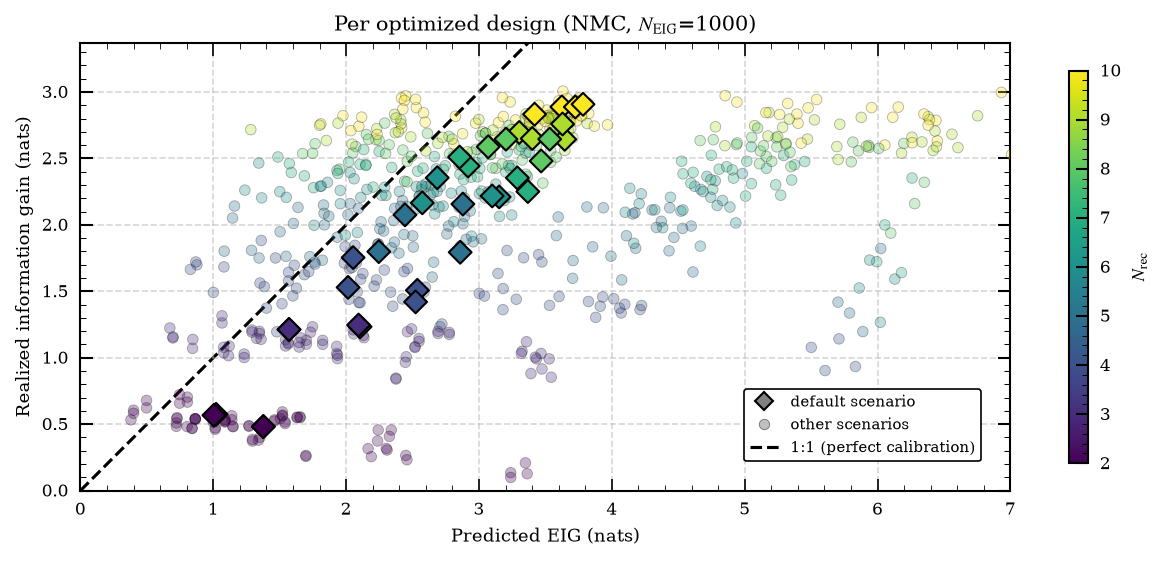

In [53]:
# =====================================================================
# OED review plots (reviewer requests):
#   (1) how do realized posterior information gains compare to the EIG?
#   (2) a score / posterior-likelihood metric of the true location.
# The design-time EIG is the *predicted* expected KL (NMC estimator on
# assumed-model samples); we compare it against the *realized* per-event
# KL obtained after running inference on synthetic events.
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

AREA = "full"
AREA_TITLE = "Full Area"

# --- realized per-event quantities (added to the per-event frames) ---
#  realized information gain (KL prior->posterior) = posterior_info - prior_info
#  score of the true location                      = -log p(truth)
for _df in (summary_statistics, random_stats_df, sobol_stats_df):
    _df["realized_ig"] = _df["posterior_information"] - _df["prior_information"]
    _df["neglogscore"] = -np.log(_df["p_posterior"].clip(lower=1e-30))

# --- design-time predicted EIG lookup (fresh, unflipped drop_gradient) ---
# merge on a sign-safe key (drop_mean disambiguates attenuation; the notebook
# flips drop_gradient in summary_statistics, so it is left out of the key).
_eig_key = ["design", "model_prior", "velocity_model", "vel_sigma",
            "noise_correlation", "drop_mean", "optimisation",
            "EIG_method", "EIG_N", "N_rec"]
eig_lookup = pd.read_csv("generate_designs/data/design_data.csv")
eig_lookup = eig_lookup[eig_lookup["study_area"] == AREA]
eig_lookup = eig_lookup.groupby(_eig_key, as_index=False)["EIG"].mean()

# single-estimator optimized designs (default prior/estimator, all physical
# scenarios) so the calibration cloud is well populated.
_opt = filter_set_defaults(
    summary_statistics,
    ["velocity_model", "vel_sigma", "drop_mean", "drop_gradient", "noise_correlation"],
)
_opt = _opt[(_opt["N_rec"] >= 2) & (_opt["N_rec"] <= 10)]

# flag the canonical default scenario (gradient velocity model, default
# vel_sigma / noise correlation / attenuation) so it can be highlighted.
_opt = _opt.copy()
_opt["is_default"] = _opt.index.isin(filter_set_defaults(_opt, []).index)

per_design = _opt.groupby(_eig_key, as_index=False).agg(
    realized_ig=("realized_ig", "mean"),
    is_default=("is_default", "max"),
)
per_design["is_default"] = per_design["is_default"].astype(bool)
eig_vs_realized = per_design.merge(eig_lookup, on=_eig_key, how="inner")

print(f"{AREA_TITLE}: {len(eig_vs_realized)} optimized designs matched to a predicted EIG "
      f"({eig_vs_realized['is_default'].sum()} of them default-scenario)")
print(eig_vs_realized.groupby("N_rec")[["EIG", "realized_ig"]].mean().round(2))

# ------------------------------- FIGURE 1 -------------------------------
norm = plt.Normalize(2, 10)
cmap = plt.get_cmap("viridis")

# (a) per-design calibration scatter: predicted EIG vs realized KL.
# Default-scenario designs are drawn opaque with a diamond marker; the other
# scenarios (other velocity models / noise / attenuation) are faded circles.
fig, ax = plt.subplots(figsize=(10, 4))
_other = eig_vs_realized[~eig_vs_realized["is_default"]]
_dflt = eig_vs_realized[eig_vs_realized["is_default"]]

ax.scatter(_other["EIG"], _other["realized_ig"],
           c=_other["N_rec"], cmap="viridis", norm=norm, marker="o",
           s=26, edgecolor="k", linewidths=0.4, alpha=0.3, zorder=3, rasterized=True)
sc = ax.scatter(_dflt["EIG"], _dflt["realized_ig"],
                c=_dflt["N_rec"], cmap="viridis", norm=norm, marker="D",
                s=60, edgecolor="k", linewidths=1.0, alpha=1.0, zorder=5, rasterized=True)

_hi = max(eig_vs_realized["EIG"].max(), eig_vs_realized["realized_ig"].max()) * 1.05
ax.plot([0, _hi], [0, _hi], "k--", lw=1.5, zorder=1, label="1:1 (perfect calibration)")
ax.set_xlim(0, _hi)
ax.set_ylim(0, eig_vs_realized["realized_ig"].max() * 1.12)
ax.set_xlabel("Predicted EIG (nats)")
ax.set_ylabel("Realized information gain (nats)")
ax.grid(True, ls="--", alpha=0.5)
_handles = [
    Line2D([0], [0], marker="D", color="w", markerfacecolor="grey", markeredgecolor="black",
           markeredgewidth=1.0, markersize=6.0, linestyle="None", label="default scenario"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="grey", markeredgecolor="black",
           markeredgewidth=0.4, markersize=5.0, alpha=0.5, linestyle="None", label="other scenarios"),
    Line2D([0], [0], color="k", ls="--", lw=1.5, label="1:1 (perfect calibration)"),
]
ax.legend(handles=_handles, loc="lower right", fontsize=7, facecolor="white")
fig.colorbar(sc, ax=ax, label=r"$N_\text{rec}$", shrink=0.85)
ax.set_title(r"Per optimized design (NMC, $N_\text{EIG}$=1000)", fontsize=10)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(0, 7)

fig.savefig(f"figures/{AREA}_eig_vs_realized_kl.pdf", bbox_inches="tight")
fig.savefig(f"figures/{AREA}_eig_vs_realized_kl.png", dpi=300, bbox_inches="tight")
plt.show()


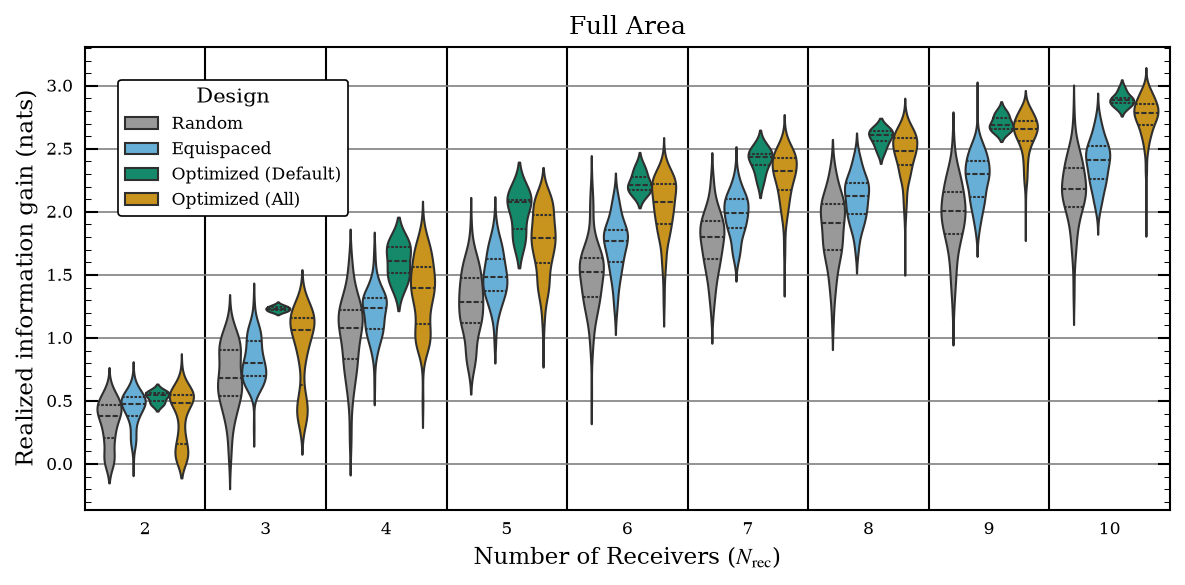

In [54]:
# ------------------------------- FIGURE 2 -------------------------------
# Realized information gain vs N_rec by design type: do the EIG-optimized
# designs actually deliver larger realized information gain than the
# random / equispaced baselines?
from copy import deepcopy
import seaborn as sns

_metrics = ["realized_ig", "neglogscore", "posterior_entropy", "distance_mean"]

# per-design values (mean over events), mirroring the distance violin cell
_design_stats_ig = (
    summary_statistics.groupby(scen_columns + ["N_rec"], as_index=False)[_metrics].mean()
)
_design_stats_ig = _design_stats_ig[_design_stats_ig["N_rec"] <= 10]
_random_ig = random_stats_df.groupby(["N_rec", "design_index"], as_index=False)[_metrics].mean()
_sobol_ig = sobol_stats_df.groupby(["N_rec", "design_index"], as_index=False)[_metrics].mean()

DESIGN_PALETTE = {
    "Random": "#999999",
    "Equispaced": "#56B4E9",
    "Optimized (Default)": "#009E73",
    "Optimized (All)": "#E69F00",
}


def design_type_violin(ax, source_grouped, source_random, source_sobol,
                       metric, ylabel, ylim=None, legend_loc="best"):
    """Violin of `metric` vs N_rec split by design type (matches distance violin)."""
    rc = deepcopy(source_random); rc["Design"] = "Random"
    sc = deepcopy(source_sobol); sc["Design"] = "Equispaced"
    od = filter_set_defaults(deepcopy(source_grouped), ["EIG_method"]); od["Design"] = "Optimized (Default)"
    oa = deepcopy(source_grouped[source_grouped["EIG_N"] == 1000]); oa["Design"] = "Optimized (All)"
    comb = pd.concat([rc, sc, oa, od])
    comb = comb[(comb["N_rec"] >= 2) & (comb["N_rec"] <= 10)]

    sns.violinplot(data=comb, x="N_rec", y=metric, hue="Design",
                   inner="quartile", bw_method="silverman", density_norm="width",
                   ax=ax, palette=DESIGN_PALETTE, hue_order=list(DESIGN_PALETTE),
                   dodge=True)
    _uN = sorted(comb["N_rec"].unique())
    for i in range(1, len(_uN)):
        ax.axvline(i - 0.5, color="k", lw=1, zorder=0)
    ax.set_xticks(range(len(_uN)))
    ax.set_xticklabels(_uN)
    ax.tick_params(axis="x", which="both", length=0)
    ax.set_xlim(-0.5, len(_uN) - 0.5)
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.set_xlabel(r"Number of Receivers ($N_\mathrm{rec}$)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(True, axis="y", linestyle="-", color="grey")
    ax.set_axisbelow(True)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(title="Design", loc=legend_loc, facecolor="white", fontsize=8)


fig, ax = plt.subplots(figsize=(8, 4))
design_type_violin(ax, _design_stats_ig, _random_ig, _sobol_ig,
                   "realized_ig", "Realized information gain (nats)",
                   legend_loc="upper left")
ax.set_title(f"{AREA_TITLE}", fontsize=12)
fig.savefig(f"figures/{AREA}_benchmark_violin_realized_kl.pdf", bbox_inches="tight")
fig.savefig(f"figures/{AREA}_benchmark_violin_realized_kl.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


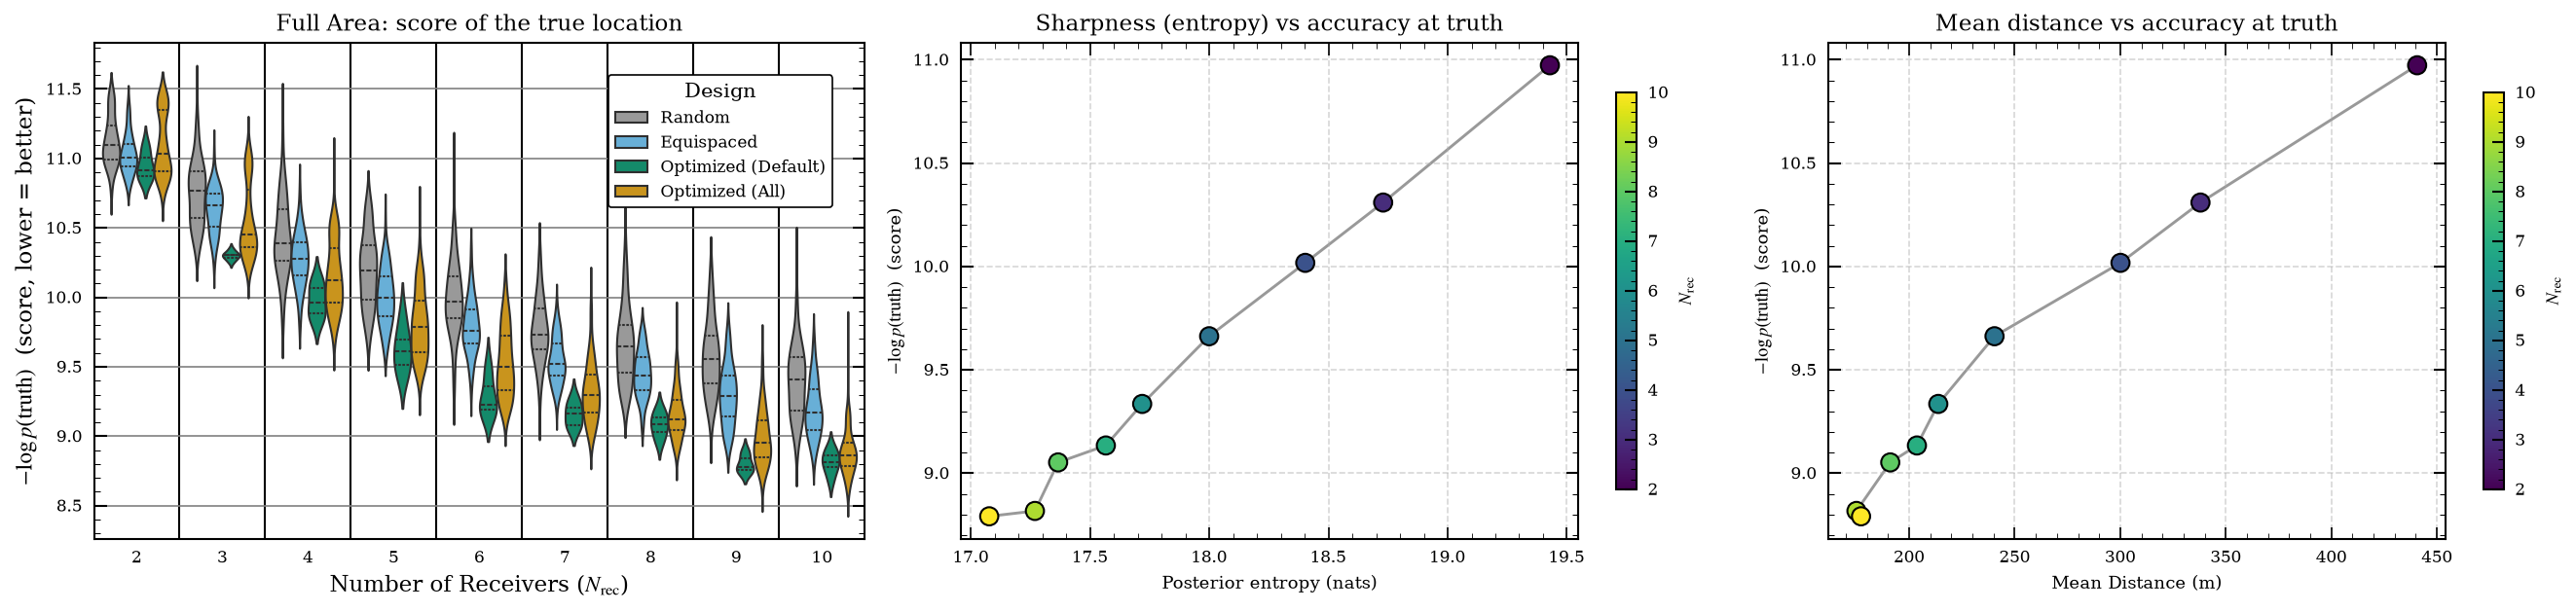

In [55]:
# ------------------------------- FIGURE 3 -------------------------------
# Score / posterior-likelihood of the TRUE location, characterised by its
# mean (-log p(truth), a proper score, lower = better) and compared against
# both the posterior entropy (sharpness) and the mean distance (accuracy).
fig, axes = plt.subplots(1, 3, figsize=(18, 4.3))

# (a) score of true location vs N_rec by design type
design_type_violin(axes[0], _design_stats_ig, _random_ig, _sobol_ig,
                   "neglogscore", r"$-\log p(\mathrm{truth})$  (score, lower = better)",
                   legend_loc="upper right")
axes[0].set_title(f"{AREA_TITLE}: score of the true location", fontsize=11)

# (b, c) mean score vs posterior entropy / mean distance, coloured by N_rec
_perN = (
    filter_set_defaults(_design_stats_ig, [])
    .groupby("N_rec")[["posterior_entropy", "neglogscore", "distance_mean"]]
    .mean().reset_index()
)
_perN = _perN[(_perN["N_rec"] >= 2) & (_perN["N_rec"] <= 10)]


def _score_scatter(ax, xcol, xlabel, title):
    ax.plot(_perN[xcol], _perN["neglogscore"], "k-", alpha=0.4, zorder=1)
    sc = ax.scatter(_perN[xcol], _perN["neglogscore"], c=_perN["N_rec"],
                    cmap="viridis", norm=plt.Normalize(2, 10), s=80,
                    edgecolor="k", linewidths=1, zorder=3)
    fig.colorbar(sc, ax=ax, label=r"$N_\text{rec}$", shrink=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$-\log p(\mathrm{truth})$  (score)")
    ax.grid(True, ls="--", alpha=0.5)
    ax.set_title(title, fontsize=11)


_score_scatter(axes[1], "posterior_entropy", "Posterior entropy (nats)",
               "Sharpness (entropy) vs accuracy at truth")
_score_scatter(axes[2], "distance_mean", quantity_labels.get("distance_mean", "Mean Distance (m)"),
               "Mean distance vs accuracy at truth")

fig.tight_layout()
fig.savefig(f"figures/{AREA}_true_location_score.pdf", bbox_inches="tight")
fig.savefig(f"figures/{AREA}_true_location_score.png", dpi=300, bbox_inches="tight")
plt.show()
